G203-47 is another wd+dm binary with a cool white dwarf. 15 day period so might be tricky to spot with TESS https://ui.adsabs.harvard.edu/abs/1999A%26A...344..897D/abstract

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fits
import os
import glob
from astropy.table import Table
from astropy.io import ascii
import astropy.units as u
import astropy.constants as const
from astropy.modeling import models, fitting
import lightkurve as lk
from scipy.interpolate import interp1d


#matplotlib set up
%matplotlib inline
from matplotlib import rcParams
rcParams["figure.figsize"] = (14, 5)
rcParams["font.size"] = 20

/home/david/micromamba/envs/stenv/lib/python3.12/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [2]:
# tic = 219085795
# star = lk.search_lightcurve('TIC219085795')
# star

In [3]:
# for sr in star:
#     # print(sr)
#     if sr.exptime == 120*u.s and sr.author=='SPOC':
#         lc = sr.download(download_dir='data/')
#         lc = lc.normalize().remove_outliers()
#         lc.scatter()

In [4]:
# pg = lc.to_periodogram(oversample_factor=10,minimum_period=4*u.minute, maximum_period=20*u.day)

In [5]:
# pg.plot()

Need to use wotan to combine all 2min data. Next step, make a spectrum a la GJ207.1. Sebastain's MUSS sample has parameters. L980-5 has similar mass and Teff

In [6]:
prox = fits.getdata('/media/david/2tb_ext_hd/hddata/mega_muscles/v24_hlsp/L-980-5/hlsp_muscles_multi_multi_l-980-5_broadband_v24_adapt-const-res-sed.fits', 1)
dmw, dmf = prox['WAVELENGTH'], prox['FLUX']

In [7]:
# phx = fits.getdata('/media/david/2tb_ext_hd/hddata/mega_muscles/v24_hlsp/GJ163/hlsp_muscles_model_phx_gj163_na_v24_component-spec.fits', 1)
# pw, pf = phx['WAVELENGTH'], phx['FLUX']
# norm = prox['NORMFAC'][-1]
# pf = pf * norm

3.1149330983671675


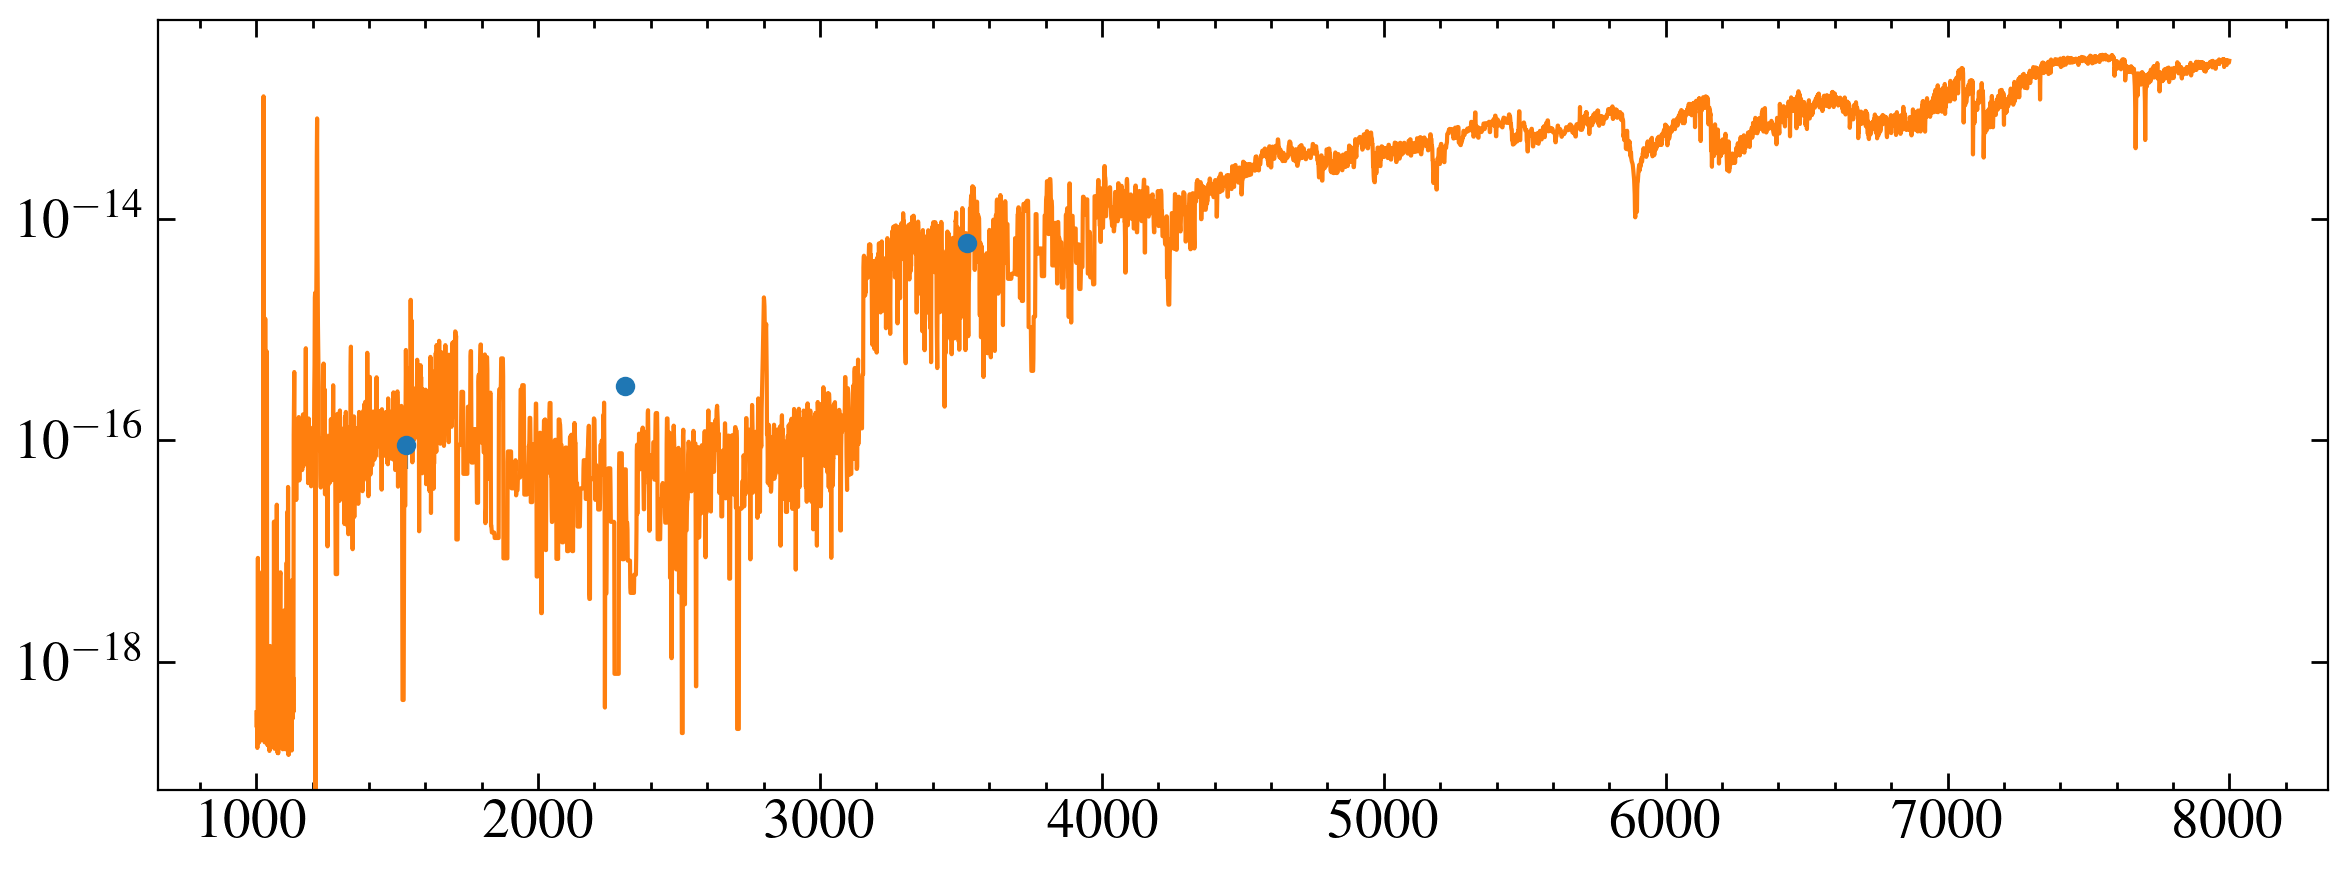

In [8]:
fig, ax = plt.subplots()

mask = (dmw >1000) & (dmw < 8000) #& (dmf > 0)
dmw1, dmf1 = dmw[mask], dmf[mask]

d_gj163 = 1000/66.0714
d_l980 = 1000/74.5644
d_g203 = 1000/131.60
# print(d_gj163, d_g203)

scale = (d_l980/d_g203)**2
print(scale)

#u, nuv and fuv photometry from vizer
phot_w = np.array([1.53e-1,  2.31e-1, 3.52e-1])*u.um
phot_f = np.array([7.00e-6, 54.5e-6, 2.50e-3])*u.Jy
phot_e = np.array([2.70e-6, 4.8e-6, 0.01e-3])*u.Jy

phot_e = phot_e/phot_f
phot_f = phot_f.to(u.erg/u.s/u.cm**2/u.AA, equivalencies=u.spectral_density(phot_w))
phot_e = phot_f*phot_e
phot_w = phot_w.to(u.AA)

ax.errorbar(phot_w, phot_f, yerr=phot_e, marker='o', ls='none')


ax.plot(dmw1, dmf1*scale)

# pmask = (pw > 1300) & (pw < 6000)
# ax.plot(pw[pmask], pf[pmask]*scale, zorder=-1)

ax.set_yscale('log')


Looks like the options for proxy spectra aren't great. PHX model and wd?

In [9]:
import prepare_phoenix_svo as pp


G = const.G
M = const.M_sun.to(u.kg)
R = const.R_sun.to(u.m)
mass = 0.2714
# teff = 5715
teff = 3279
teff_e = 64
# radius = 1.79
radius = 0.286
distance = 1000/134.5971
save_path = 'models/'
star = 'G204-47'
g = ((G*mass*M)/(radius*R)**2).to(u.cm/u.s**2)
repo = '/media/david/2tb_ext_hd/hddata/mega_muscles/data-vacuum/'

star_params = {'Teff': teff, 'logg': np.log10(g.value), 'FeH': 0.00, 'aM': 0, 'Radius':radius*u.R_sun, 'Distance':distance*u.pc, 'Teff_e':teff_e}
# pw, pf, pe = pp.make_phoenix_spectrum(star, save_path, repo, star_params, save_ecsv=True, plot=False, make_error=True)
normfac = ((radius*R)/((distance*u.pc).to(u.m)))**2

# pdata = Table.read('models/Wasp_63_phoenix_interpolated.ecsv')
# pw, pf, pe = pdata['WAVELENGTH'], pdata['FLUX'], pdata['ERROR']

In [10]:
pdata = Table.read('models/G204-47_phoenix_interpolated.ecsv')
pw, pf, pe = pdata['WAVELENGTH'], pdata['FLUX'], pdata['ERROR']
# plt.plot(pw, pf*normfac)
# plt.yscale('log')
# plt.xscale('log')

Make model with wd, phoenix and mgii lines?

In [11]:
path = '/media/david/2tb_ext_hd/hddata/carmenes_binary/'
mods = glob.glob('{}models_1628872352/koester2/*.dat.txt'.format(path))
mods

['/media/david/2tb_ext_hd/hddata/carmenes_binary/models_1628872352/koester2/da05000_800.dk.dat.txt',
 '/media/david/2tb_ext_hd/hddata/carmenes_binary/models_1628872352/koester2/da05250_800.dk.dat.txt',
 '/media/david/2tb_ext_hd/hddata/carmenes_binary/models_1628872352/koester2/da05500_800.dk.dat.txt',
 '/media/david/2tb_ext_hd/hddata/carmenes_binary/models_1628872352/koester2/da05750_800.dk.dat.txt',
 '/media/david/2tb_ext_hd/hddata/carmenes_binary/models_1628872352/koester2/da06000_800.dk.dat.txt',
 '/media/david/2tb_ext_hd/hddata/carmenes_binary/models_1628872352/koester2/da06250_800.dk.dat.txt',
 '/media/david/2tb_ext_hd/hddata/carmenes_binary/models_1628872352/koester2/da06500_800.dk.dat.txt',
 '/media/david/2tb_ext_hd/hddata/carmenes_binary/models_1628872352/koester2/da06750_800.dk.dat.txt',
 '/media/david/2tb_ext_hd/hddata/carmenes_binary/models_1628872352/koester2/da07000_800.dk.dat.txt',
 '/media/david/2tb_ext_hd/hddata/carmenes_binary/models_1628872352/koester2/da07250_800.dk.

In [12]:
rwd = 0.0127*u.Rsun
wd_scale = (rwd.to(u.m)/(d_g203*u.pc).to(u.m))**2


[8.96470249e-17 3.06191581e-16 6.04888579e-15] erg / (Angstrom s cm2) [3.45781382e-17 2.69673319e-17 2.41955432e-17] erg / (Angstrom s cm2)


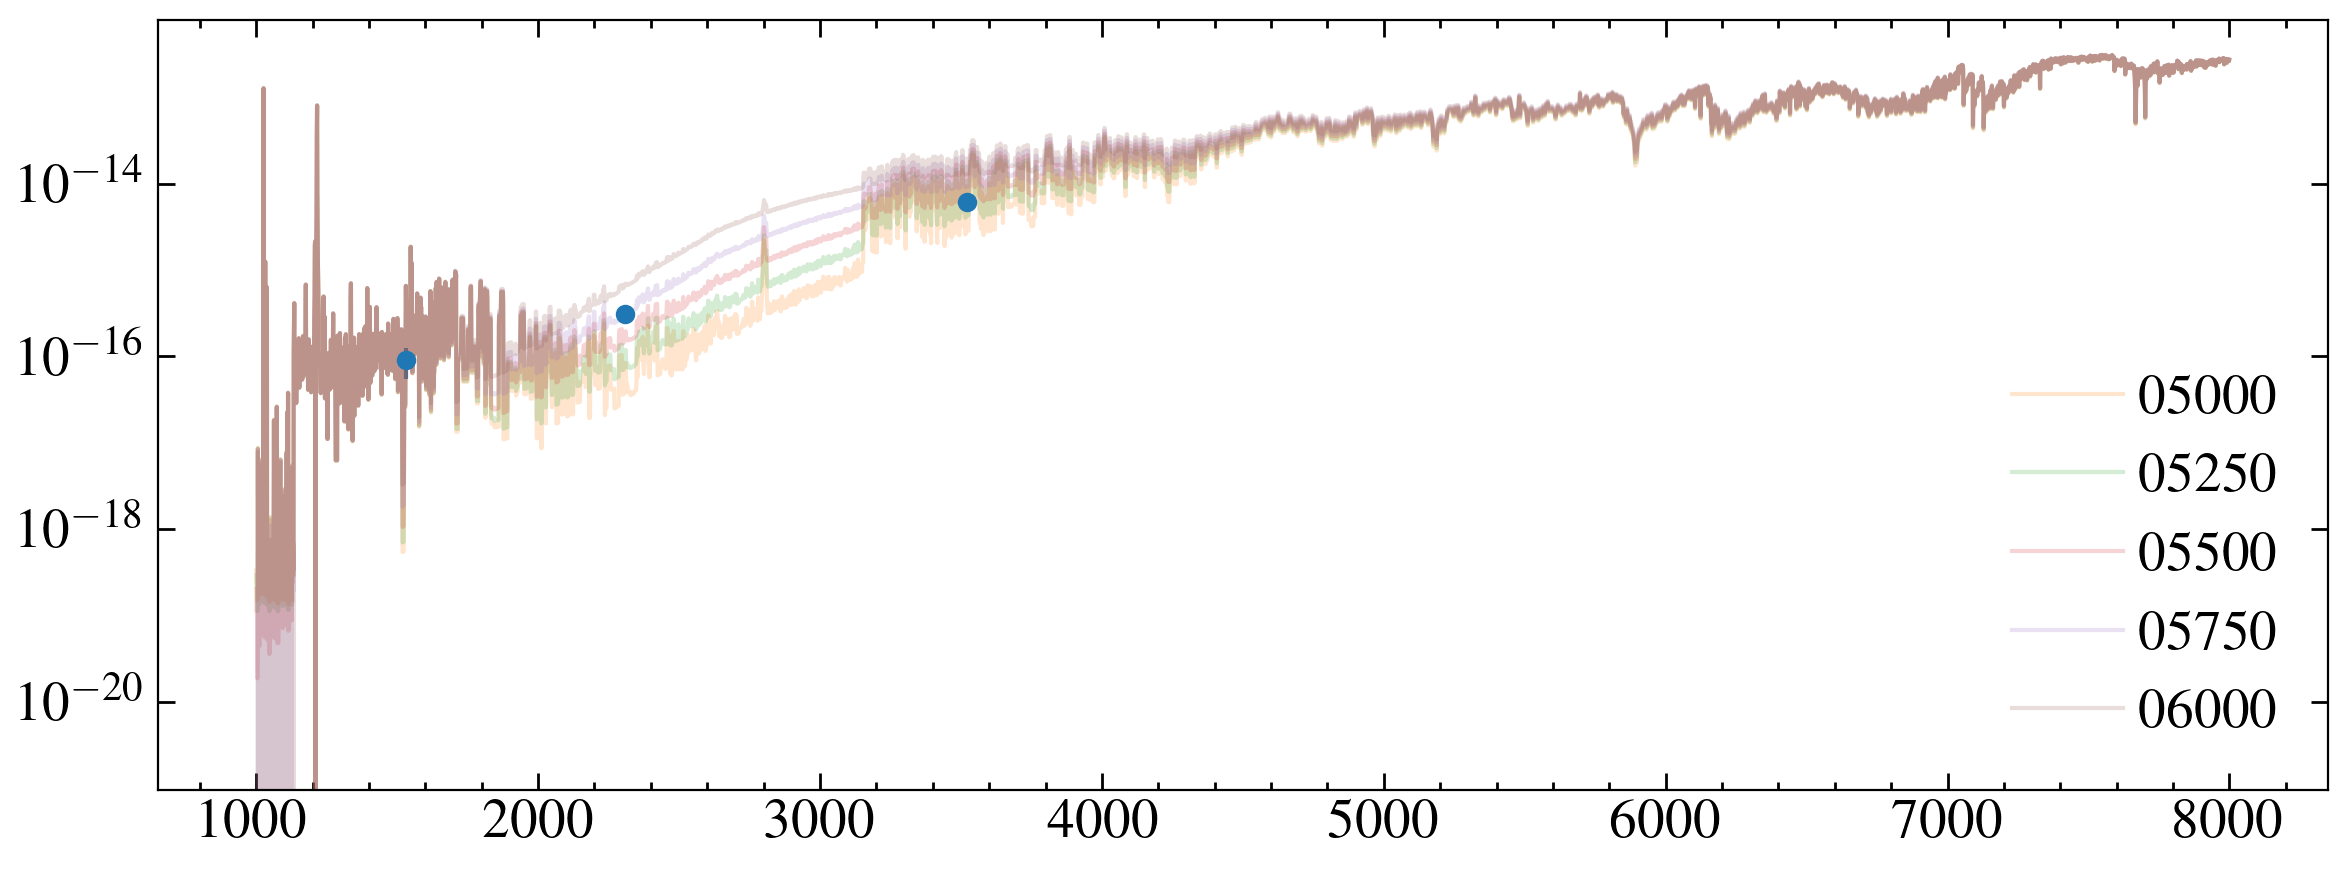

In [13]:
fig, ax = plt.subplots()

pmask = (pw > 1300) & (pw < 6000)
pwi, pfi = pw[pmask], pf[pmask]*normfac
pwi, pfi = pp.smear(pwi, pfi, 1000)


ax.errorbar(phot_w, phot_f, yerr=phot_e, marker='o', ls='none')
print(phot_f, phot_e)



# ax.plot(pwi, pfi)

for model in mods[0:5]:
    tmod = os.path.split(model)[1][2:7]
    mw, mf = np.loadtxt(model, unpack=True)
    wdmask =  (mw > 1300) & (mw < 6000)
    mw, mf = mw[wdmask], mf[wdmask]*wd_scale
    mfi = interp1d(mw, mf, fill_value='extrapolate')(pwi)
    mfi = mfi+pfi
    mfi = interp1d(mw, mf, fill_value='extrapolate')(dmw1)
    mfi = mfi+(dmf1*scale)
    
    
    ax.plot(dmw1, mfi, alpha=0.2, label = tmod)
    # ax.plot(mw[wdmask], mf[wdmask]*wd_scale, alpha=0.2)
# ax.plot(dmw1, dmf1*scale)
ax.legend()

ax.set_yscale('log')


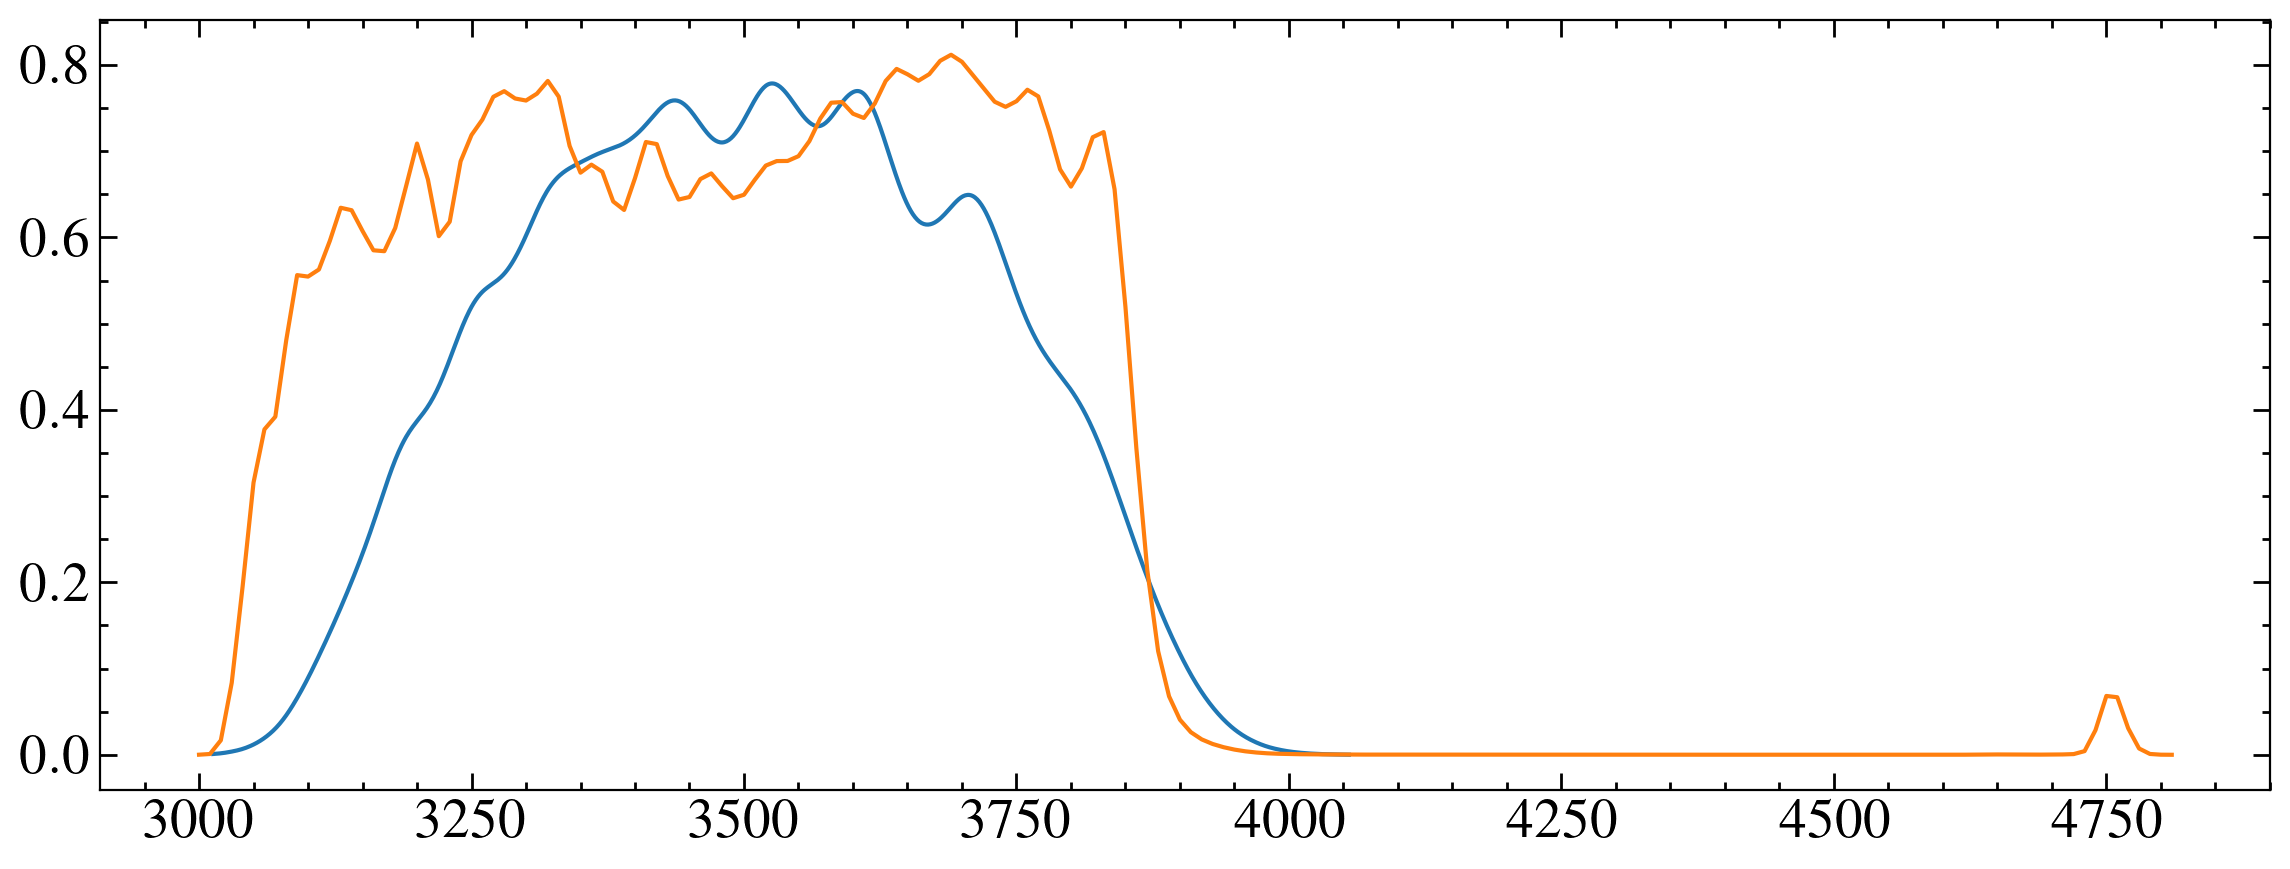

In [14]:
uw, up = np.loadtxt('/home/david/work/filters/sdss/prime/SLOAN_SDSS.uprime_filter.dat', unpack=True)
plt.plot(uw, up)
uw, up = np.loadtxt('/home/david/work/filters/uvot/Swift_UVOT.U_trn.dat', unpack=True)
plt.plot(uw, up)


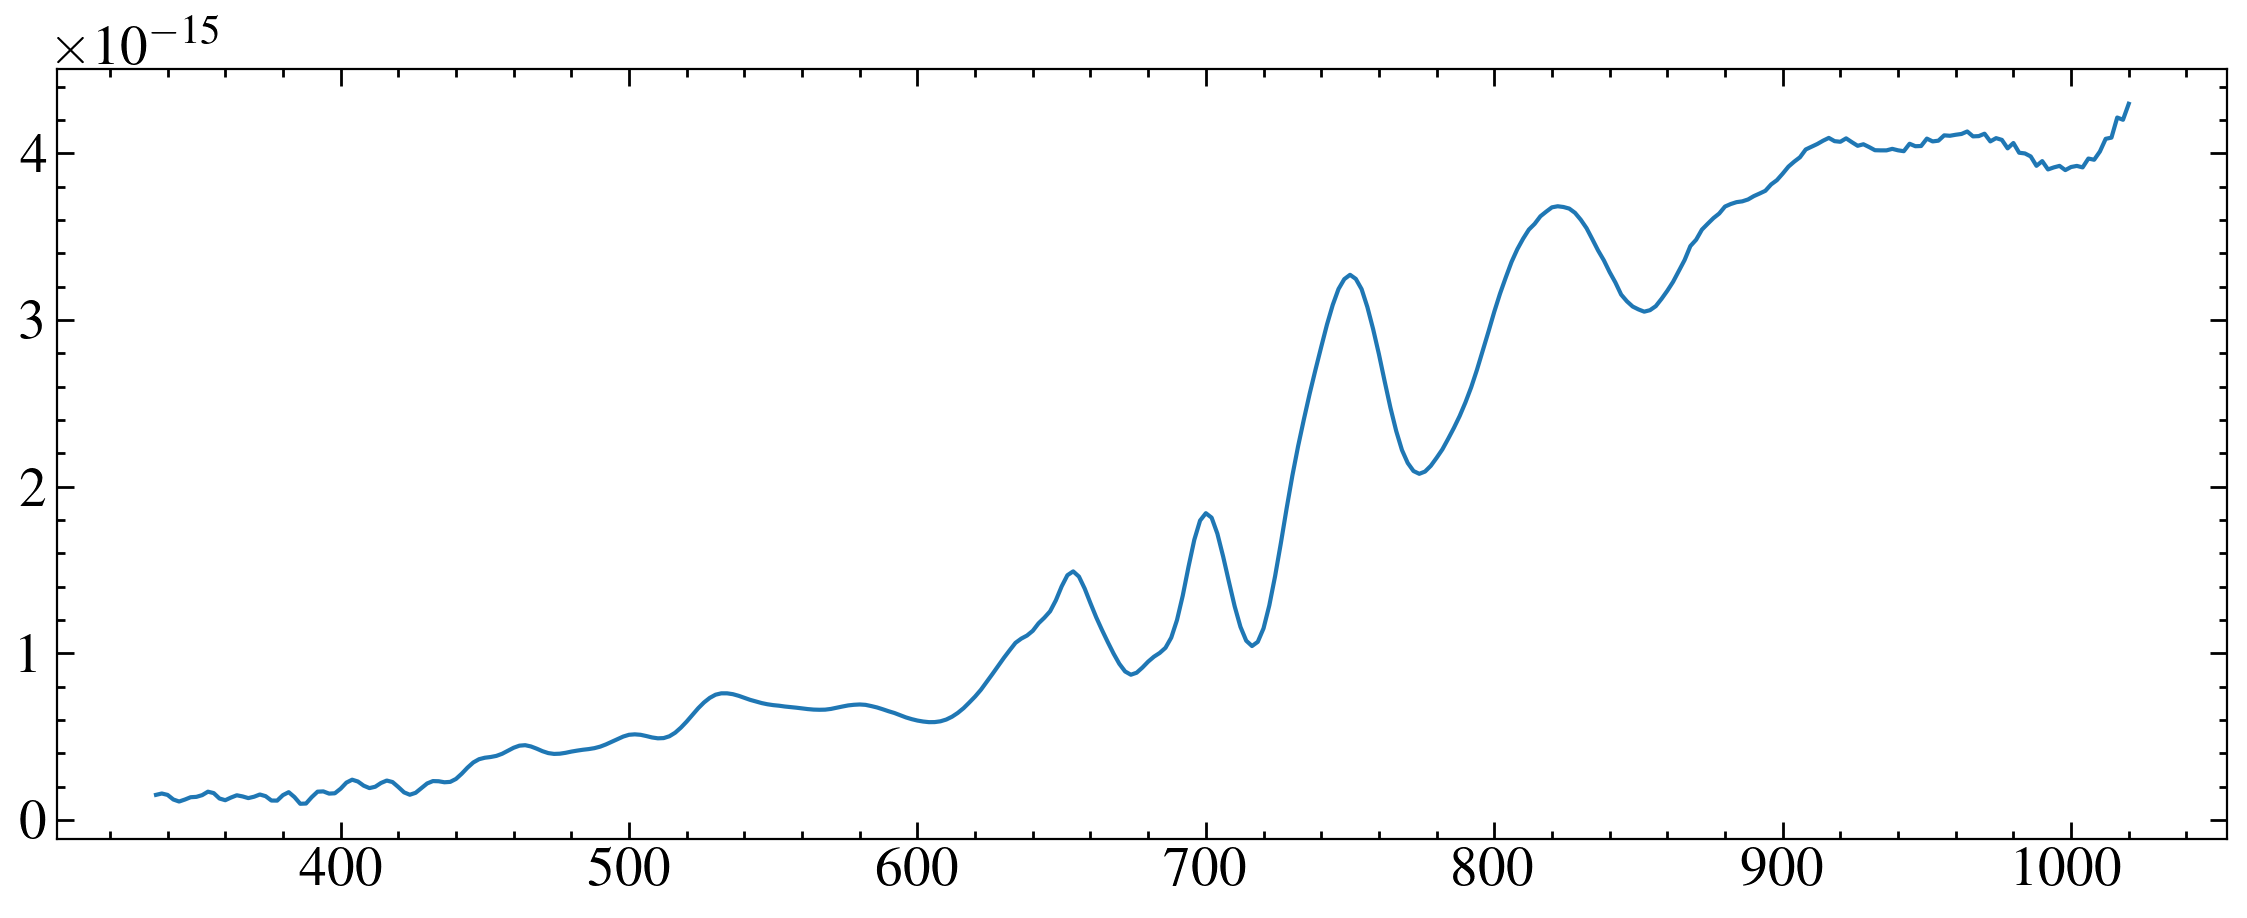

In [15]:
gaia = Table.read('data/g203_gaiadr3_sampled_mean_spectra_1355264565043431040.vot')
plt.plot(gaia['wavelength'], gaia['flux'])

In [16]:
gaia

type,wavelength,flux,flux_error
,nm,W / (nm m2),
object,float64,float32,float32
XP,336.0,1.5136446e-16,3.748029e-17
XP,338.0,1.5953564e-16,2.790904e-17
XP,340.0,1.5114598e-16,2.2418926e-17
XP,342.0,1.2354582e-16,1.958952e-17
XP,344.0,1.1142852e-16,1.826131e-17
XP,346.0,1.231983e-16,1.80776e-17
XP,348.0,1.3712008e-16,1.8844888e-17
XP,350.0,1.3940751e-16,2.0261748e-17


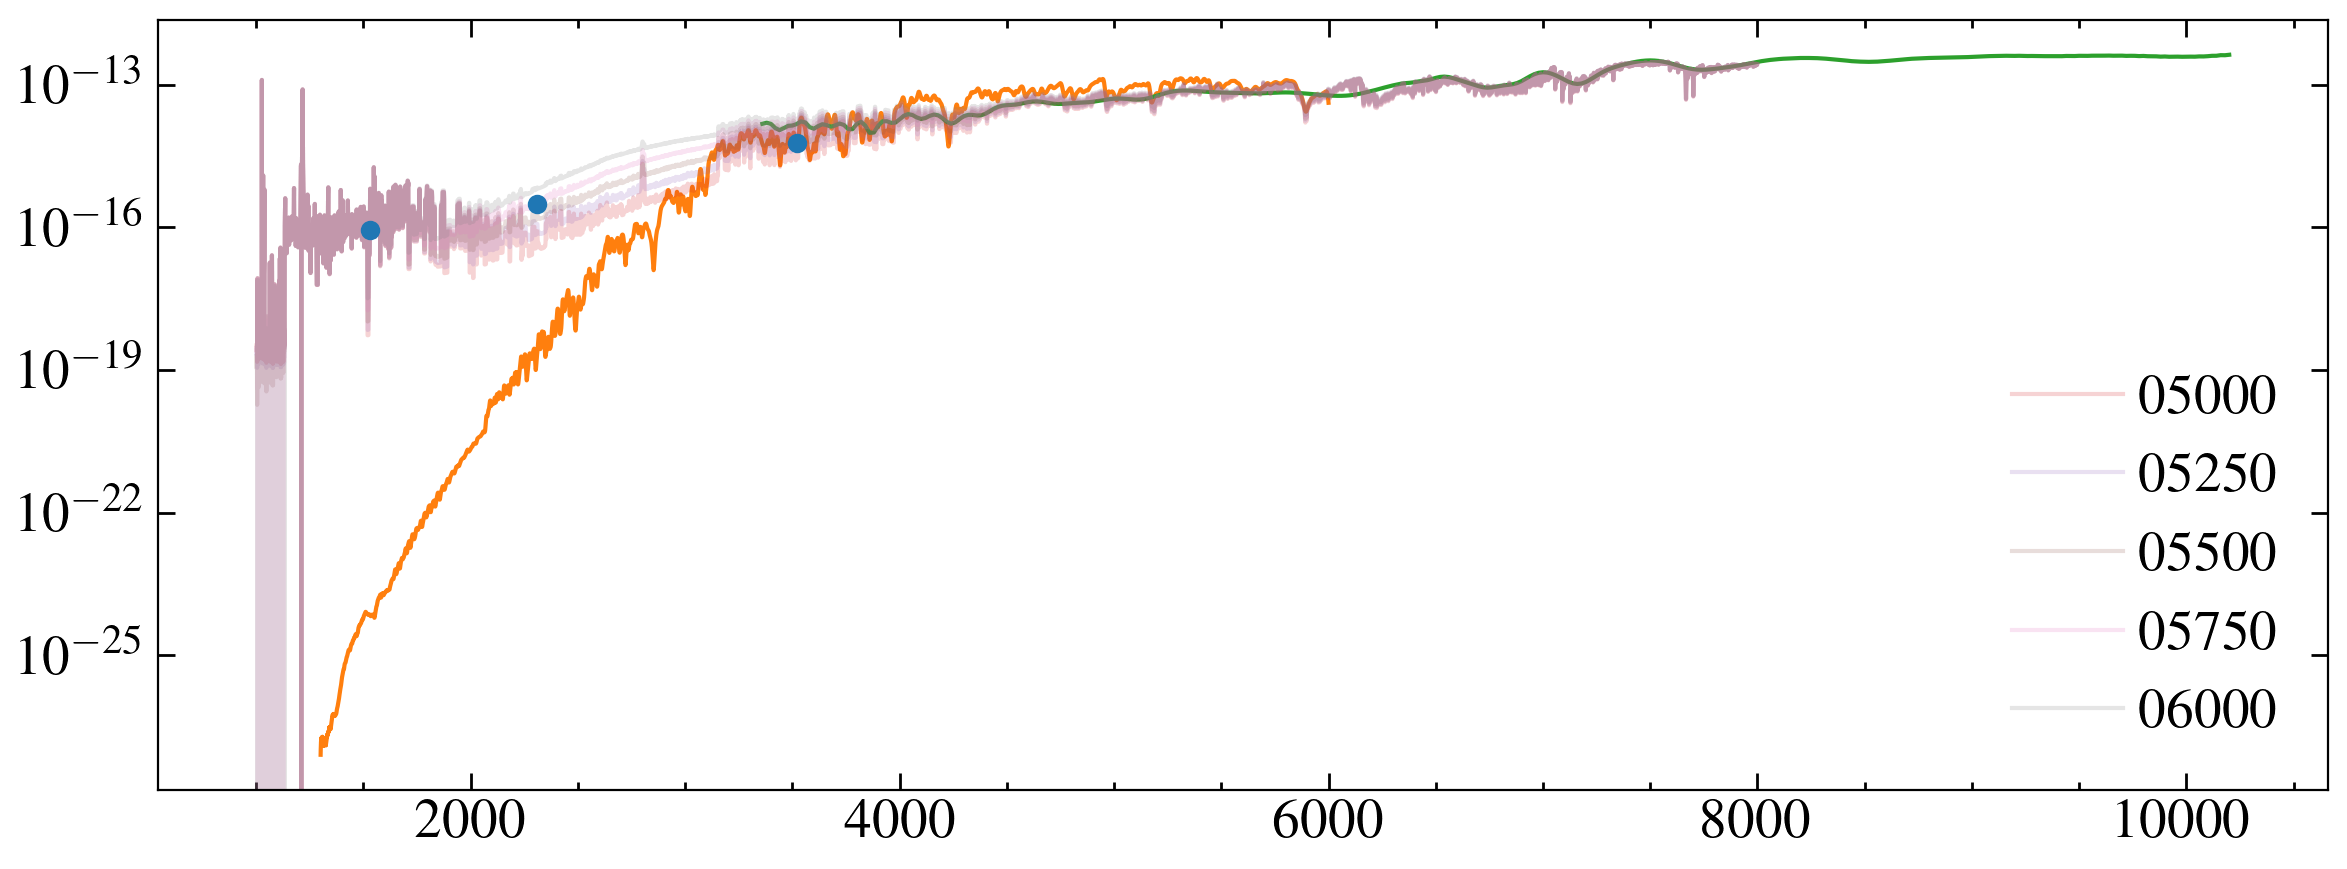

In [17]:
fig, ax = plt.subplots()

pmask = (pw > 1300) & (pw < 6000)
pwi, pfi = pw[pmask], pf[pmask]*normfac
pwi, pfi = pp.smear(pwi, pfi, 1000)


ax.errorbar(phot_w, phot_f, yerr=phot_e, marker='o', ls='none')



ax.plot(pwi, pfi)

ax.plot(gaia['wavelength']*10, gaia['flux']*(u.W/u.m**2/u.nm).to(u.erg/u.s/u.cm**2/u.AA))
for model in mods[0:5]:
    tmod = os.path.split(model)[1][2:7]
    mw, mf = np.loadtxt(model, unpack=True)
    wdmask =  (mw > 1300) & (mw < 6000)
    mw, mf = mw[wdmask], mf[wdmask]*wd_scale
    mfi = interp1d(mw, mf, fill_value='extrapolate')(pwi)
    mfi = mfi+pfi
    mfi = interp1d(mw, mf, fill_value='extrapolate')(dmw1)
    mfi = mfi+(dmf1*scale)
    
    
    ax.plot(dmw1, mfi, alpha=0.2, label = tmod)
    # ax.plot(mw[wdmask], mf[wdmask]*wd_scale, alpha=0.2)
# ax.plot(dmw1, dmf1*scale)

ax.legend()

ax.set_yscale('log')


Ok so the problem is in the U band measurement. Rescale the proxy to Gaia? Got some Swift time

In [18]:
print(phot_w)
print(phot_f)
print(phot_e)

[1530. 2310. 3520.] Angstrom
[8.96470249e-17 3.06191581e-16 6.04888579e-15] erg / (Angstrom s cm2)
[3.45781382e-17 2.69673319e-17 2.41955432e-17] erg / (Angstrom s cm2)


In [19]:
import gPhoton

In [20]:
skypos = [257.383, 43.680]


In [21]:
nuv_exps = gPhoton.gFind(band='NUV', skypos=skypos)

NUV: 146.0s (raw) in 2 exposures.
    [ 838018145.995, 838018223.995 ], 78.000 seconds
    [ 864038432.995, 864038500.995 ], 68.000 seconds


In [22]:
fuv_exps = gPhoton.gFind(band='FUV', skypos=skypos)

FUV: 146.0s (raw) in 2 exposures.
    [ 838018145.995, 838018223.995 ], 78.000 seconds
    [ 864038432.995, 864038500.995 ], 68.000 seconds


In [23]:
target = 'g203-47'
step_size = 20.
phot_rad = 0.0045
ap_in = 0.0050
ap_out = 0.0060

In [24]:
# # nuv_photon_events = gPhoton.gAperture(band='NUV', skypos=skypos, stepsz=step_size, radius=phot_rad, 
# #                                       annulus=[ap_in, ap_out], verbose=3, csvfile='galex/{}_nuv_{}s_lc.csv'.format(target, step_size),
# #                                       overwrite=True)
# nuv_photon_events = gPhoton.gAperture(band='NUV', skypos=skypos, radius=phot_rad, 
#                                       annulus=[ap_in, ap_out], verbose=3, csvfile='galex/{}_nuv_all_lc.csv'.format(target),
#                                       overwrite=True)

In [25]:
# # print(nuv_photon_events['flux_bgsub'], nuv_photon_events['flux_bgsub_err'])

# weights = 1/(nuv_photon_events['flux_bgsub_err']**2)
# flux = np.average(nuv_photon_events['flux_bgsub'], weights= weights)
# err =  (1 / np.sum(weights))**0.5

# print(flux, err)

In [26]:
# fuv_photon_events = gPhoton.gAperture(band='FUV', skypos=skypos, stepsz=step_size, radius=phot_rad, 
# #                                       annulus=[ap_in, ap_out], verbose=3, csvfile='galex/{}_fuv_{}s_lc.csv'.format(target, step_size),
# #                                       overwrite=True)

# fuv_photon_events = gPhoton.gAperture(band='FUV', skypos=skypos, radius=phot_rad, 
#                                       annulus=[ap_in, ap_out], verbose=3, csvfile='galex/{}_fuv_all_lc.csv'.format(target, step_size),
#                                       overwrite=True)

In [27]:
# print(fuv_photon_events['flux_bgsub'], fuv_photon_events['flux_bgsub_err'])

# weights = 1/(fuv_photon_events['flux_bgsub_err']**2)
# flux = np.average(fuv_photon_events['flux_bgsub'], weights= weights)
# err =  (1 / np.sum(weights))**0.5

# print(flux, err)

3.926286076329794e-16
2.026535152276017e-16


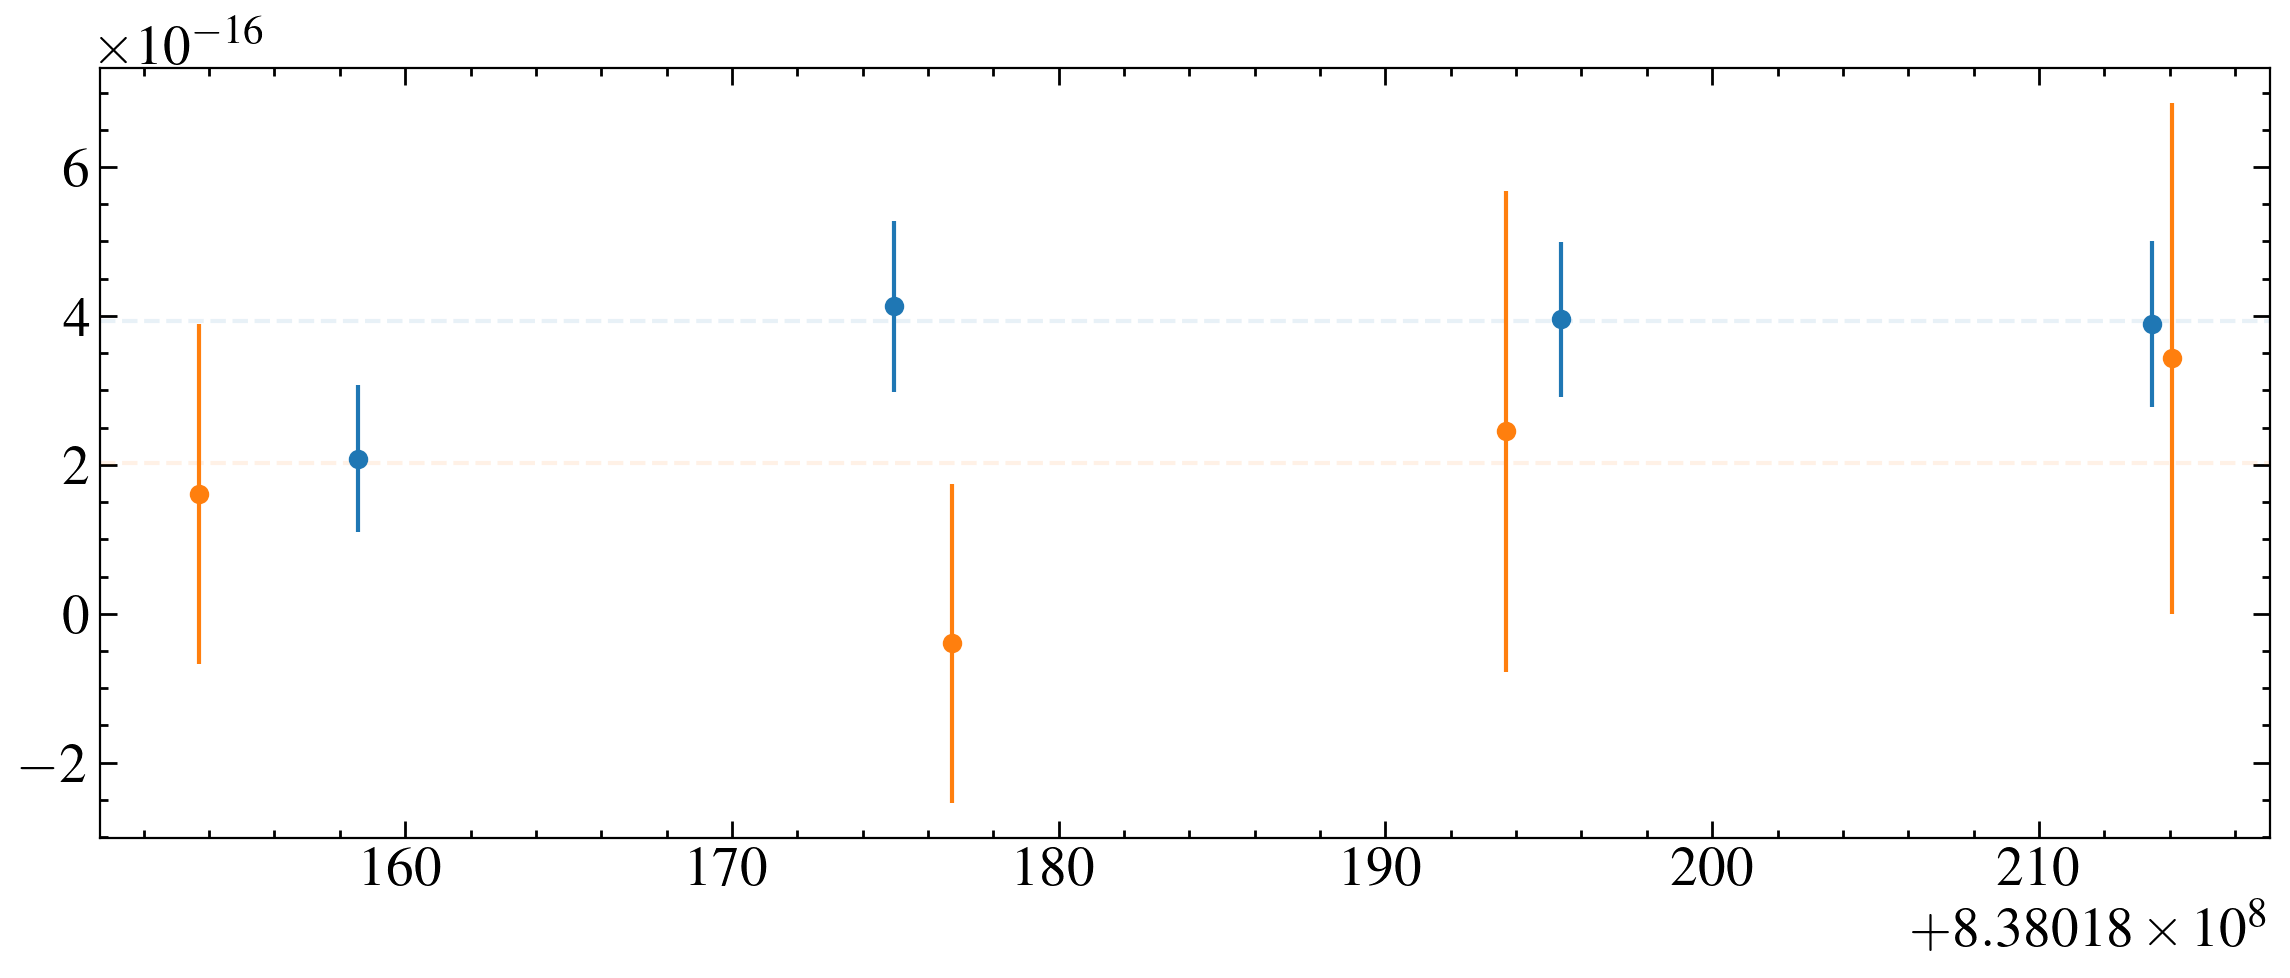

5.296533325507314e-16
7.592421611946143e-17


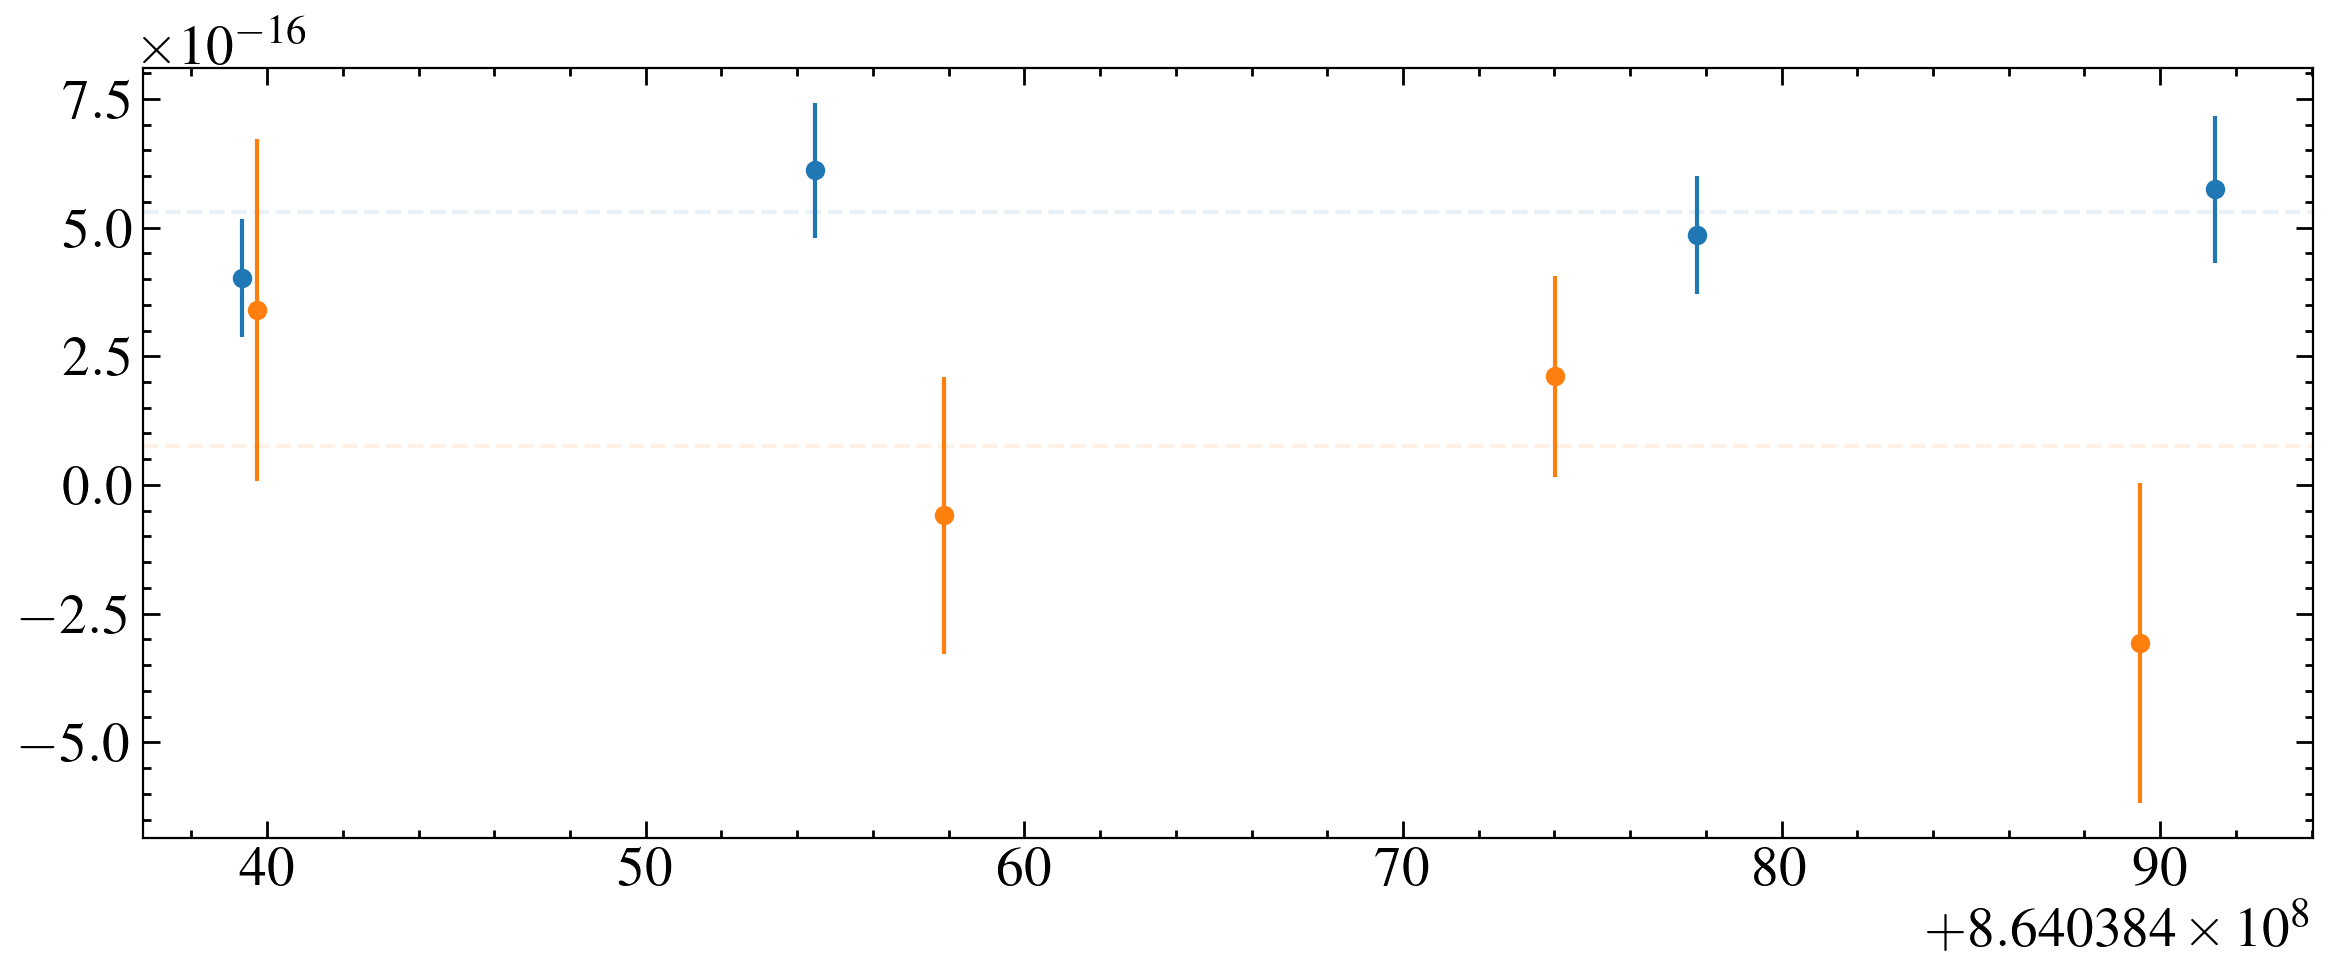

In [28]:
nuv= Table.read('galex/{}_nuv_{}s_lc.csv'.format(target, step_size))
fuv= Table.read('galex/{}_fuv_{}s_lc.csv'.format(target, step_size))

t, f, e, q = nuv['t_mean'], nuv['flux_bgsub'], nuv['flux_bgsub_err'], nuv['flags']
tf, ff, ef, qf = fuv['t_mean'], fuv['flux_bgsub'], fuv['flux_bgsub_err'], fuv['flags']
# t, f, e = t[q==0], f[q==0], e[q==0]
#plt.errorbar(t-t[0], f, yerr=e, ls='none', marker='o')
t0s, t1s = nuv_exps['NUV']['t0'], nuv_exps['NUV']['t1']
for t0, t1 in zip(t0s, t1s):
    mask = (t >=t0-100) & (t <=t1+100)
    fmask = (tf >=t0-100) & (tf <=t1+100)
    print(np.median(f[mask]))
    plt.axhline(np.median(f[mask]), ls='--', c='C0', alpha=0.1)
    plt.axhline(np.median(ff[fmask]), ls='--', c='C1', alpha=0.1)
    print(np.median(ff[fmask]))
    plt.errorbar(t[mask], f[mask], yerr=e[mask], ls='none', marker='o')
    plt.errorbar(tf[fmask], ff[fmask], yerr=ef[fmask], ls='none', marker='o')
#     plt.xlim(t0-20, t0+1397.)
    plt.show()
   # if (t1 - t0) > 900:
#     lc = lk.LightCurve(time=t[mask]*u.s, flux=f[mask], flux_err=e[mask])
#     pg = lc.to_periodogram(oversample_factor= 10, minimum_period=20*u.s, maximum_period=200*u.s)
#     plt.plot(pg.period.to(u.s), pg.power)
#     print(pg.period_at_max_power.to(u.s))
    plt.show()

Aperture size? insignificant

In [29]:
# rads = np.arange(0.004, 0.008, 0.0005)
# fluxes = []
# errs = []
# for rad in rads:
#     ap_in = rad +0.005
#     ap_out = rad +0.015

#     fuv_photon_events = gPhoton.gAperture(band='FUV', skypos=skypos, radius=rad, 
#                                           annulus=[ap_in, ap_out], verbose=0)
    
#     weights = 1/(fuv_photon_events['flux_bgsub_err']**2)
#     flux = np.average(fuv_photon_events['flux_bgsub'], weights= weights)
#     err =  (1 / np.sum(weights))**0.5
#     fluxes.append(flux)
#     errs.append(err)
    
    
    
# plt.errorbar(rads, fluxes, yerr = errs, marker='o', ls='none')

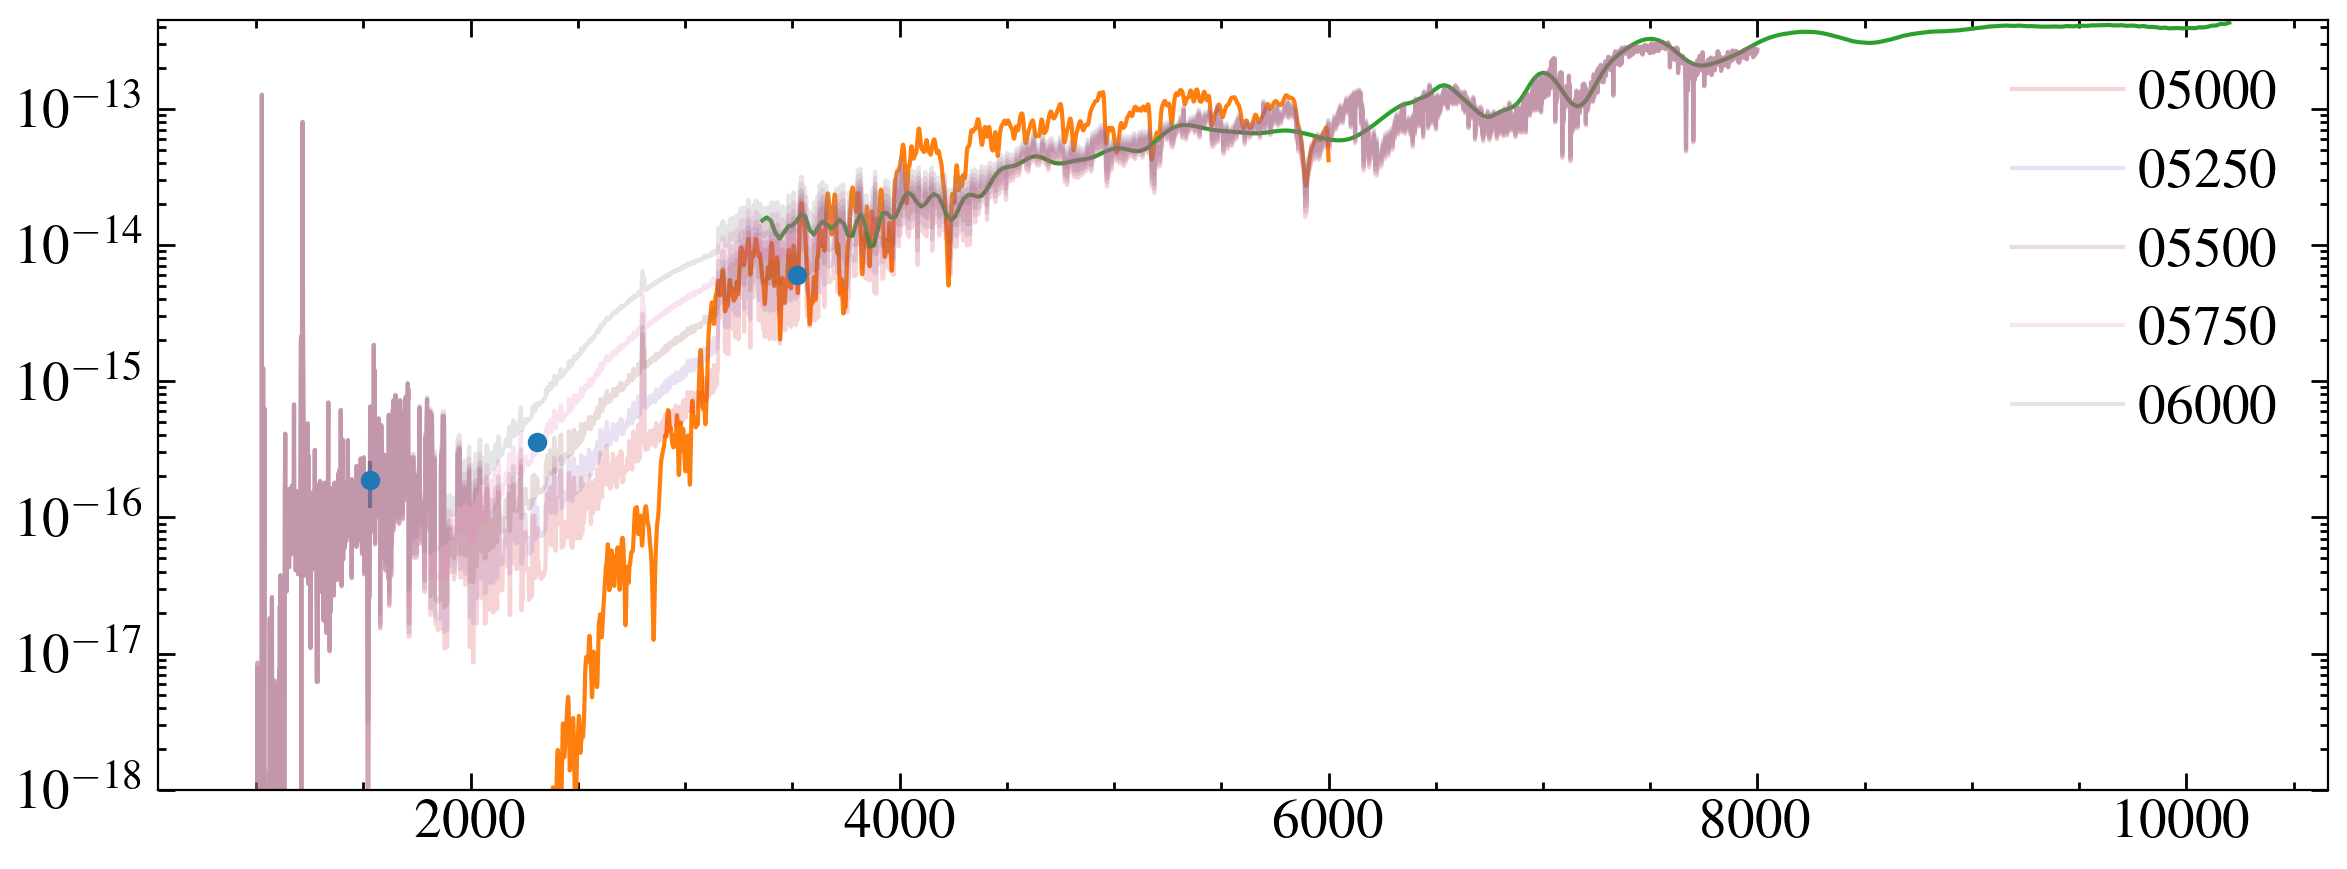

In [30]:
fig, ax = plt.subplots()

pmask = (pw > 1300) & (pw < 6000)
pwi, pfi = pw[pmask], pf[pmask]*normfac
pwi, pfi = pp.smear(pwi, pfi, 1000)


#with updated galex
phot_w = [1530, 2310, 3520,]

 
phot_f = [1.8820923094427784e-16, 3.557310200972079e-16, 6.04888579e-15] 
phot_e = [7.080414587154201e-17,3.2290504470423134e-17, 2.41955432e-17]

ax.errorbar(phot_w, phot_f, yerr=phot_e, marker='o', ls='none')
 




ax.plot(pwi, pfi)

ax.plot(gaia['wavelength']*10, gaia['flux']*(u.W/u.m**2/u.nm).to(u.erg/u.s/u.cm**2/u.AA))
for model in mods[0:5]:
    tmod = os.path.split(model)[1][2:7]
    mw, mf = np.loadtxt(model, unpack=True)
    wdmask =  (mw > 1300) & (mw < 6000)
    mw, mf = mw[wdmask], mf[wdmask]*wd_scale
    mfi = interp1d(mw, mf, fill_value='extrapolate')(pwi)
    mfi = mfi+pfi
    mfi = interp1d(mw, mf, fill_value='extrapolate')(dmw1)
    mfi = mfi+(dmf1*scale)
    
    
    ax.plot(dmw1, mfi, alpha=0.2, label = tmod)
    # ax.plot(mw[wdmask], mf[wdmask]*wd_scale, alpha=0.2)
# ax.plot(dmw1, dmf1*scale)

ax.legend()
ax.set_ylim(1e-18)

ax.set_yscale('log')


Looks like 5750K works with or without the proxy

In [31]:
mods

['/media/david/2tb_ext_hd/hddata/carmenes_binary/models_1628872352/koester2/da05000_800.dk.dat.txt',
 '/media/david/2tb_ext_hd/hddata/carmenes_binary/models_1628872352/koester2/da05250_800.dk.dat.txt',
 '/media/david/2tb_ext_hd/hddata/carmenes_binary/models_1628872352/koester2/da05500_800.dk.dat.txt',
 '/media/david/2tb_ext_hd/hddata/carmenes_binary/models_1628872352/koester2/da05750_800.dk.dat.txt',
 '/media/david/2tb_ext_hd/hddata/carmenes_binary/models_1628872352/koester2/da06000_800.dk.dat.txt',
 '/media/david/2tb_ext_hd/hddata/carmenes_binary/models_1628872352/koester2/da06250_800.dk.dat.txt',
 '/media/david/2tb_ext_hd/hddata/carmenes_binary/models_1628872352/koester2/da06500_800.dk.dat.txt',
 '/media/david/2tb_ext_hd/hddata/carmenes_binary/models_1628872352/koester2/da06750_800.dk.dat.txt',
 '/media/david/2tb_ext_hd/hddata/carmenes_binary/models_1628872352/koester2/da07000_800.dk.dat.txt',
 '/media/david/2tb_ext_hd/hddata/carmenes_binary/models_1628872352/koester2/da07250_800.dk.

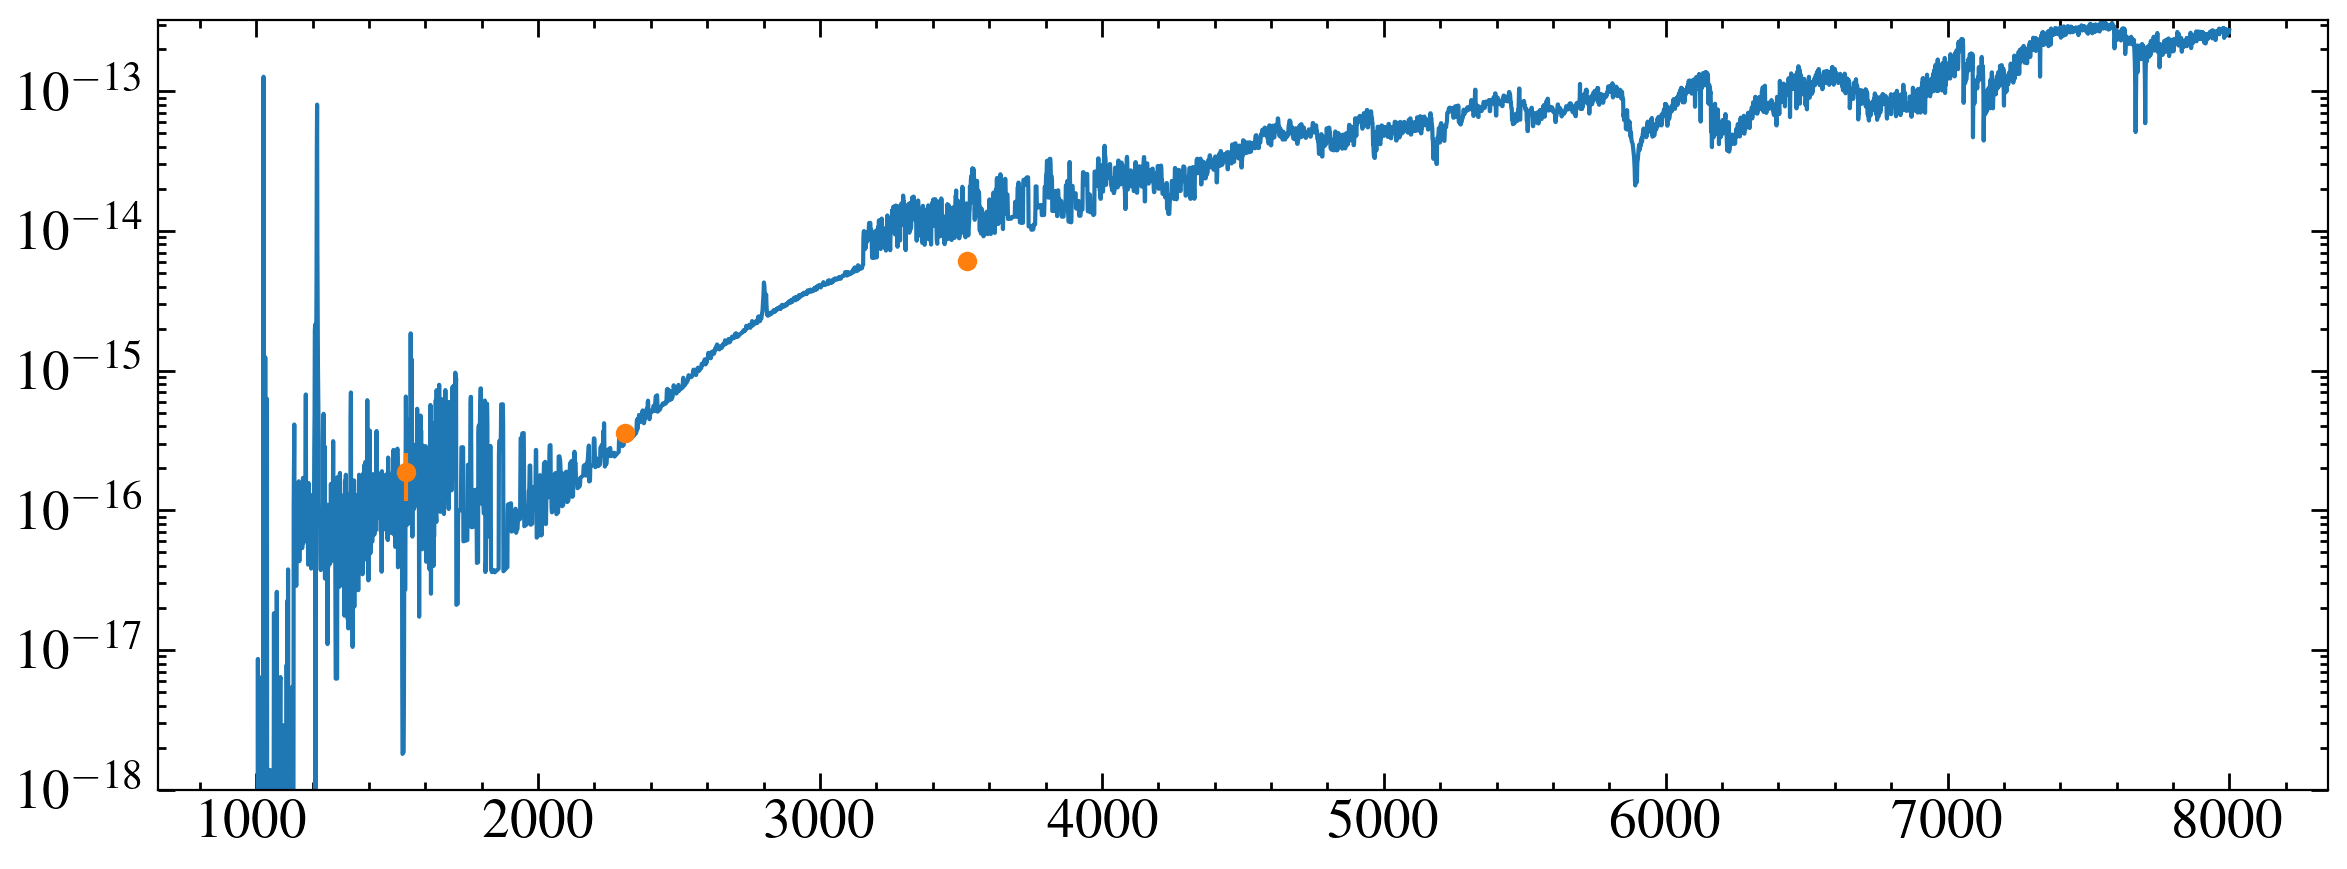

In [32]:
fig, ax = plt.subplots()

mw, mf = np.loadtxt(mods[3], unpack=True)
wdmask =  (mw > 1000) & (mw < 6000)
mw, mf = mw[wdmask], mf[wdmask]*wd_scale
mfi = interp1d(mw, mf, fill_value='extrapolate')(dmw1)
mfi = mfi+(dmf1*scale)
ax.plot(dmw1, mfi, label = tmod)
ax.errorbar(phot_w, phot_f, yerr=phot_e, marker='o', ls='none')

ax.set_ylim(1e-18)

ax.set_yscale('log')

new_mod = Table([dmw1, mfi], names =['#WAVELENGTH', 'FLUX'])
# ascii.write(new_mod, 'g203_model.dat', format='basic')

Got some swift data. First: Compare U band data from a 10as apertute with a 5as. 5 is standard, 10 looked better.

In [33]:
spath = '/media/david/2tb_ext_hd/hddata/carmenes_binary/g203-047/swift/working/'
ubands = glob.glob('{}*phot_2.fits'.format(spath))
print(ubands)
uvbands = np.hstack((glob.glob('{}*phot_1.fits'.format(spath)), glob.glob('{}*phot_3.fits'.format(spath))))
(print(uvbands))

['/media/david/2tb_ext_hd/hddata/carmenes_binary/g203-047/swift/working/5as_g203-047_uvot_phot_2.fits', '/media/david/2tb_ext_hd/hddata/carmenes_binary/g203-047/swift/working/g203-047_uvot_phot_2.fits']
['/media/david/2tb_ext_hd/hddata/carmenes_binary/g203-047/swift/working/g203-047_uvot_phot_1.fits'
 '/media/david/2tb_ext_hd/hddata/carmenes_binary/g203-047/swift/working/g203-047_uvot_phot_3.fits']


In [34]:
cenwaves = dict(V=5468, B=4392, U=3465,UVW1=2600, UVM2=2246, UVW2=1928)
fwhms = dict(V=769, B=975, U=785, UVW1=693, UVM2=498, UVW2=657)

[41.411957]
[54.712135]
[0.98315865]


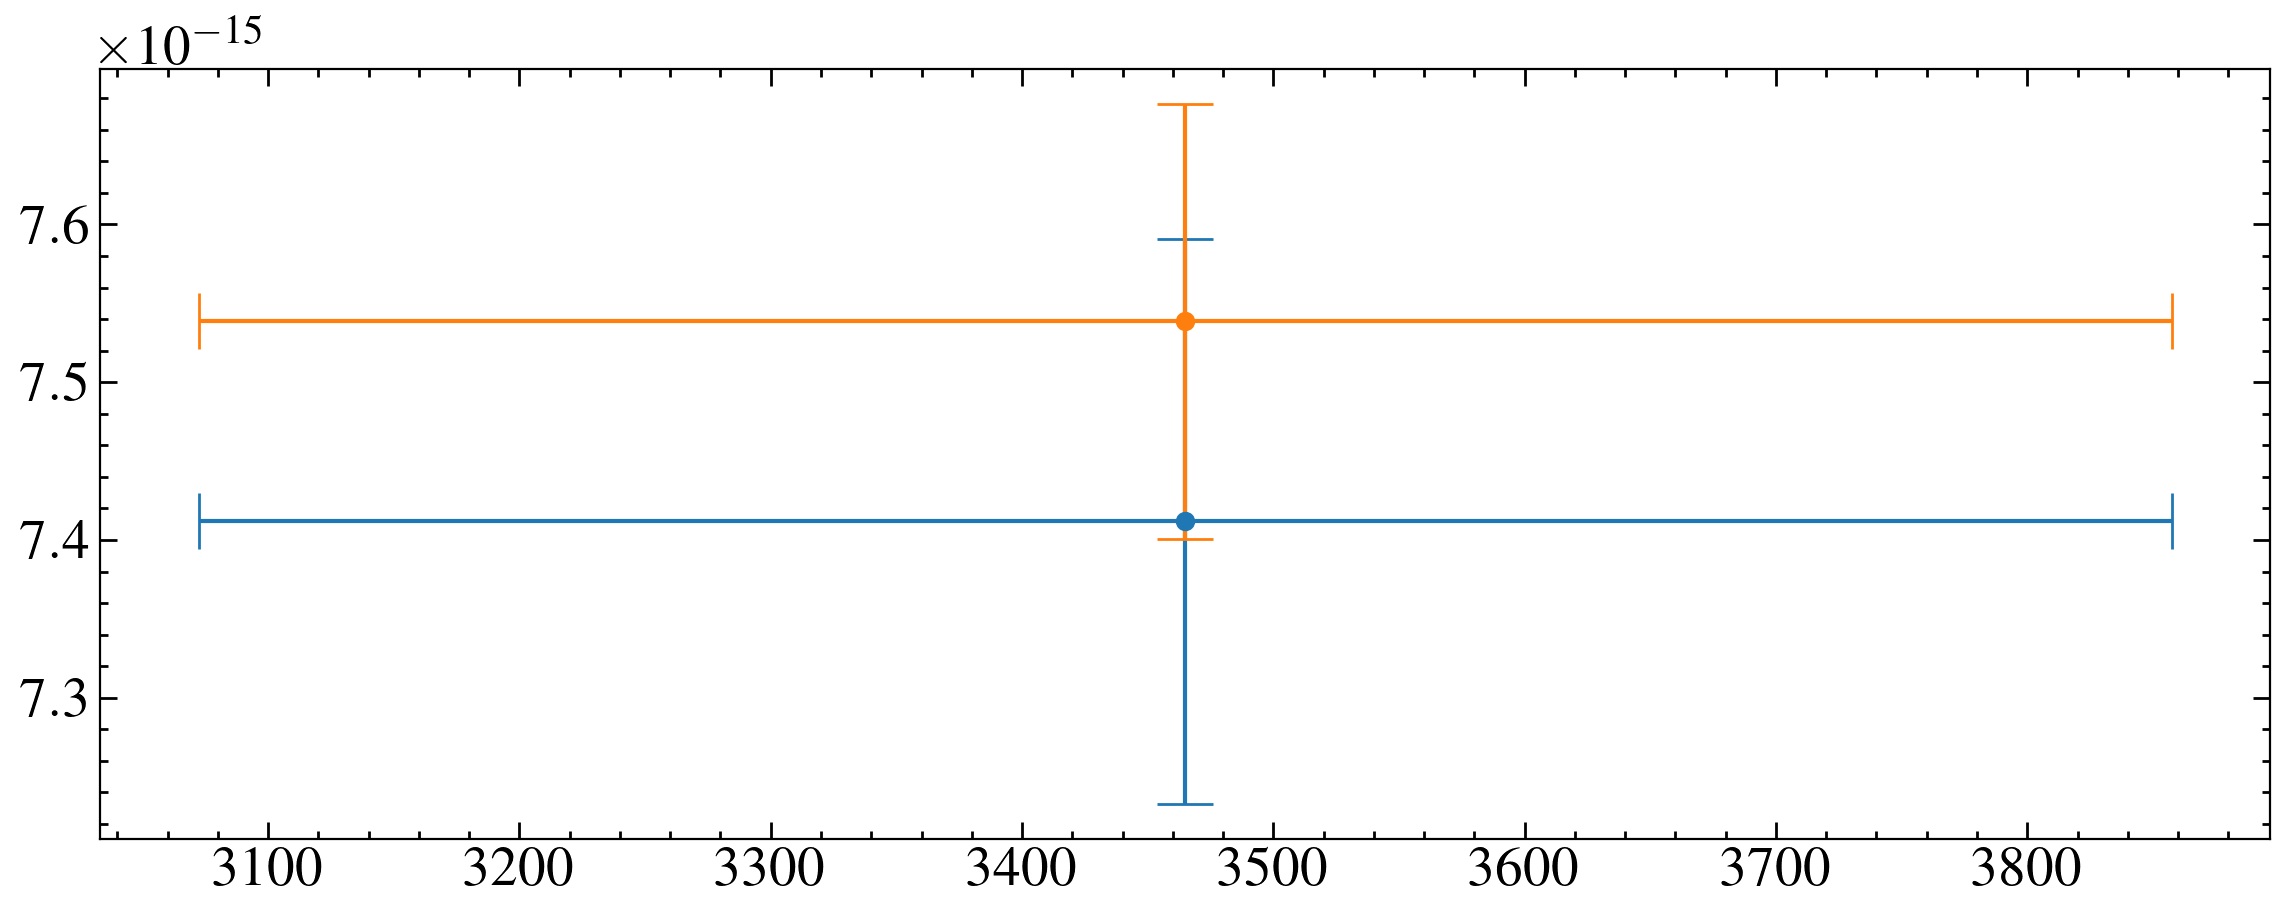

[11.82439]
[10.652814]
[0.9830357]


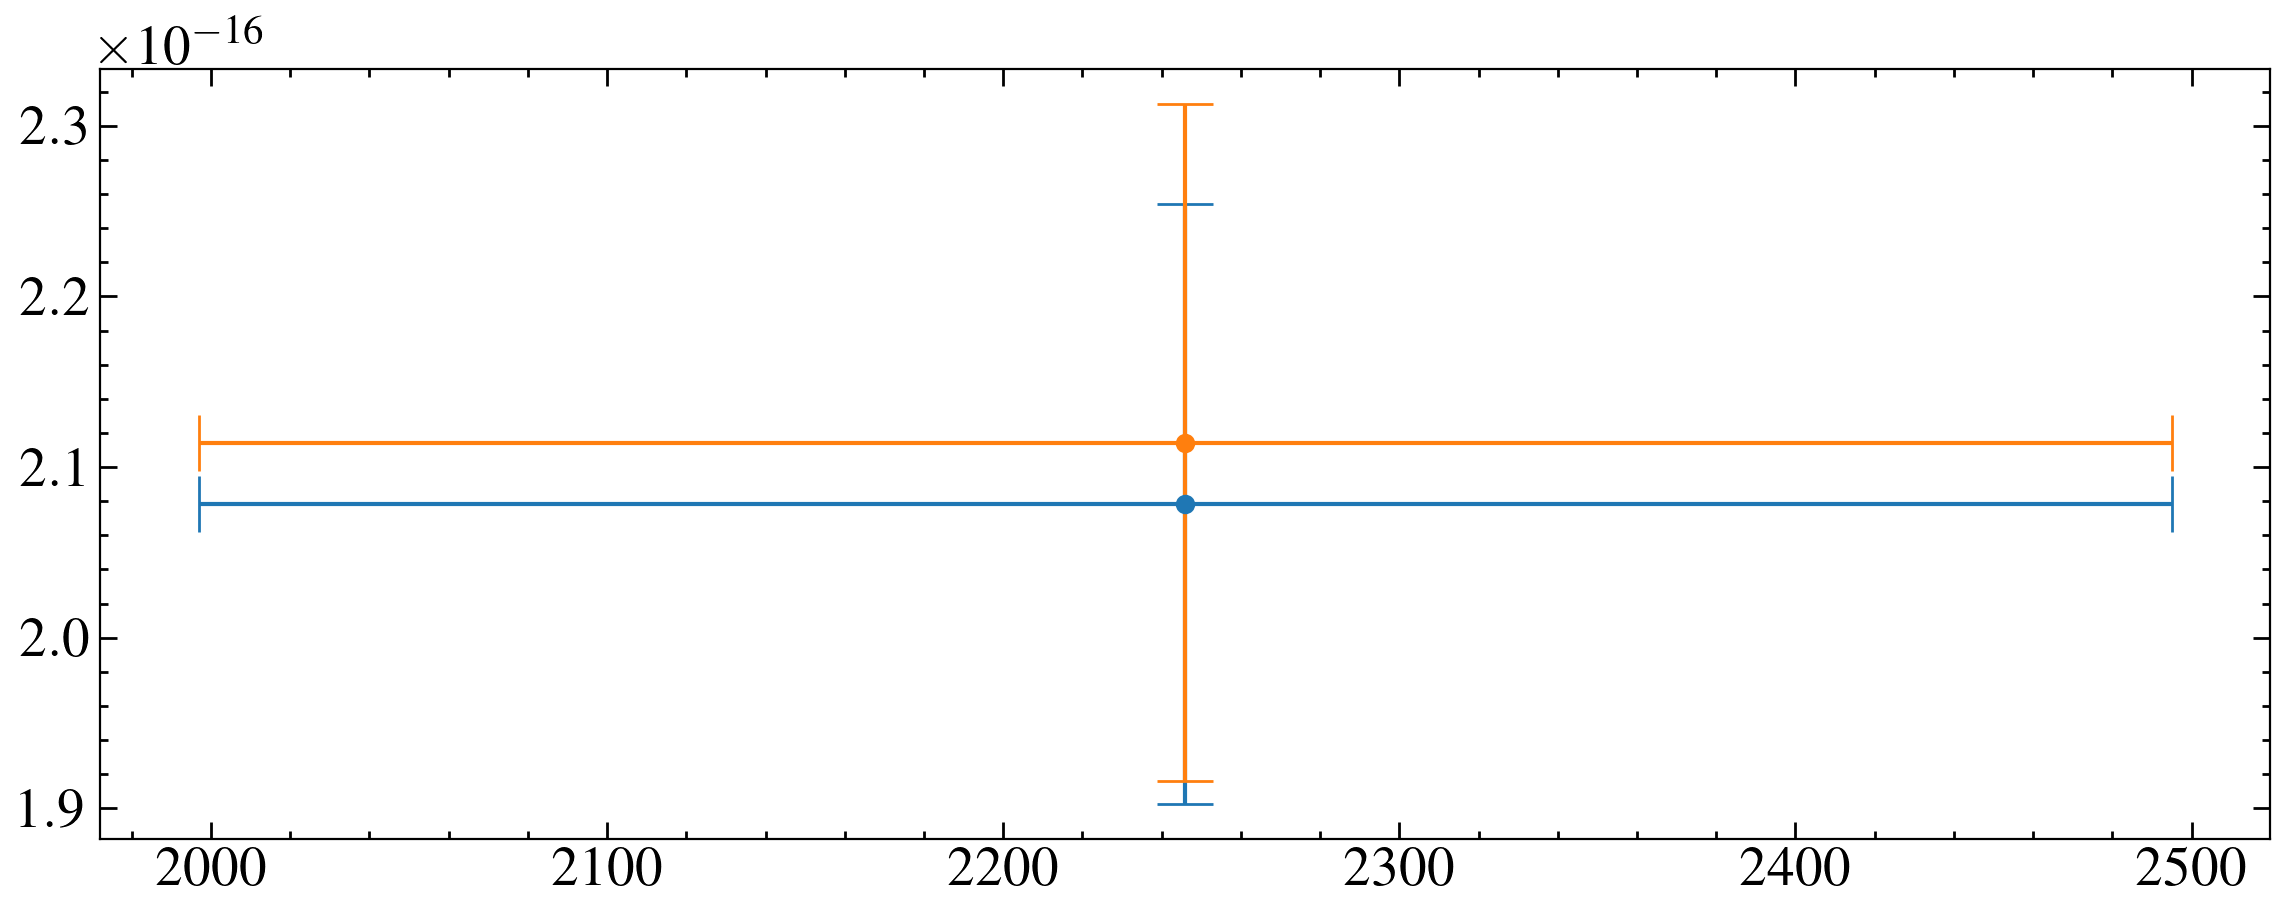

In [35]:
for i, phot in enumerate(ubands):
    data = fits.getdata(phot, 1)
    w, fwhm = cenwaves[data['FILTER'][0]], fwhms[data['FILTER'][0]]
    f, e = data['AB_FLUX_AA'], data['AB_FLUX_AA_ERR']
    print(f/e)
    plt.errorbar(w, f, yerr=e, xerr=fwhm/2, marker='o', ls='none', capsize=10)
    if i == 0:
        fi = f
    else:
        ratio = fi/f
        print(ratio)
plt.show()

for i, phot in enumerate(uvbands):
    data = fits.getdata(phot, 1)
    w, fwhm = cenwaves[data['FILTER'][0]], fwhms[data['FILTER'][0]]
    f, e = data['AB_FLUX_AA'], data['AB_FLUX_AA_ERR']
    print(f/e)
    
    plt.errorbar(w, f, yerr=e, xerr=fwhm/2, marker='o', ls='none', capsize=10)
    if i == 0:
        fi = f
    else:
        ratio = fi/f
        print(ratio)
plt.show()

10as is higher? Not by much though. 2% in it. No need to worry. S/N better on the 10as one, use that. UVM2s are consistant with no change.

3465 [7.411776e-15] [1.7897673e-16]
2246 2.0942781e-16 1.3159325e-17


(1500.0, 4000.0)

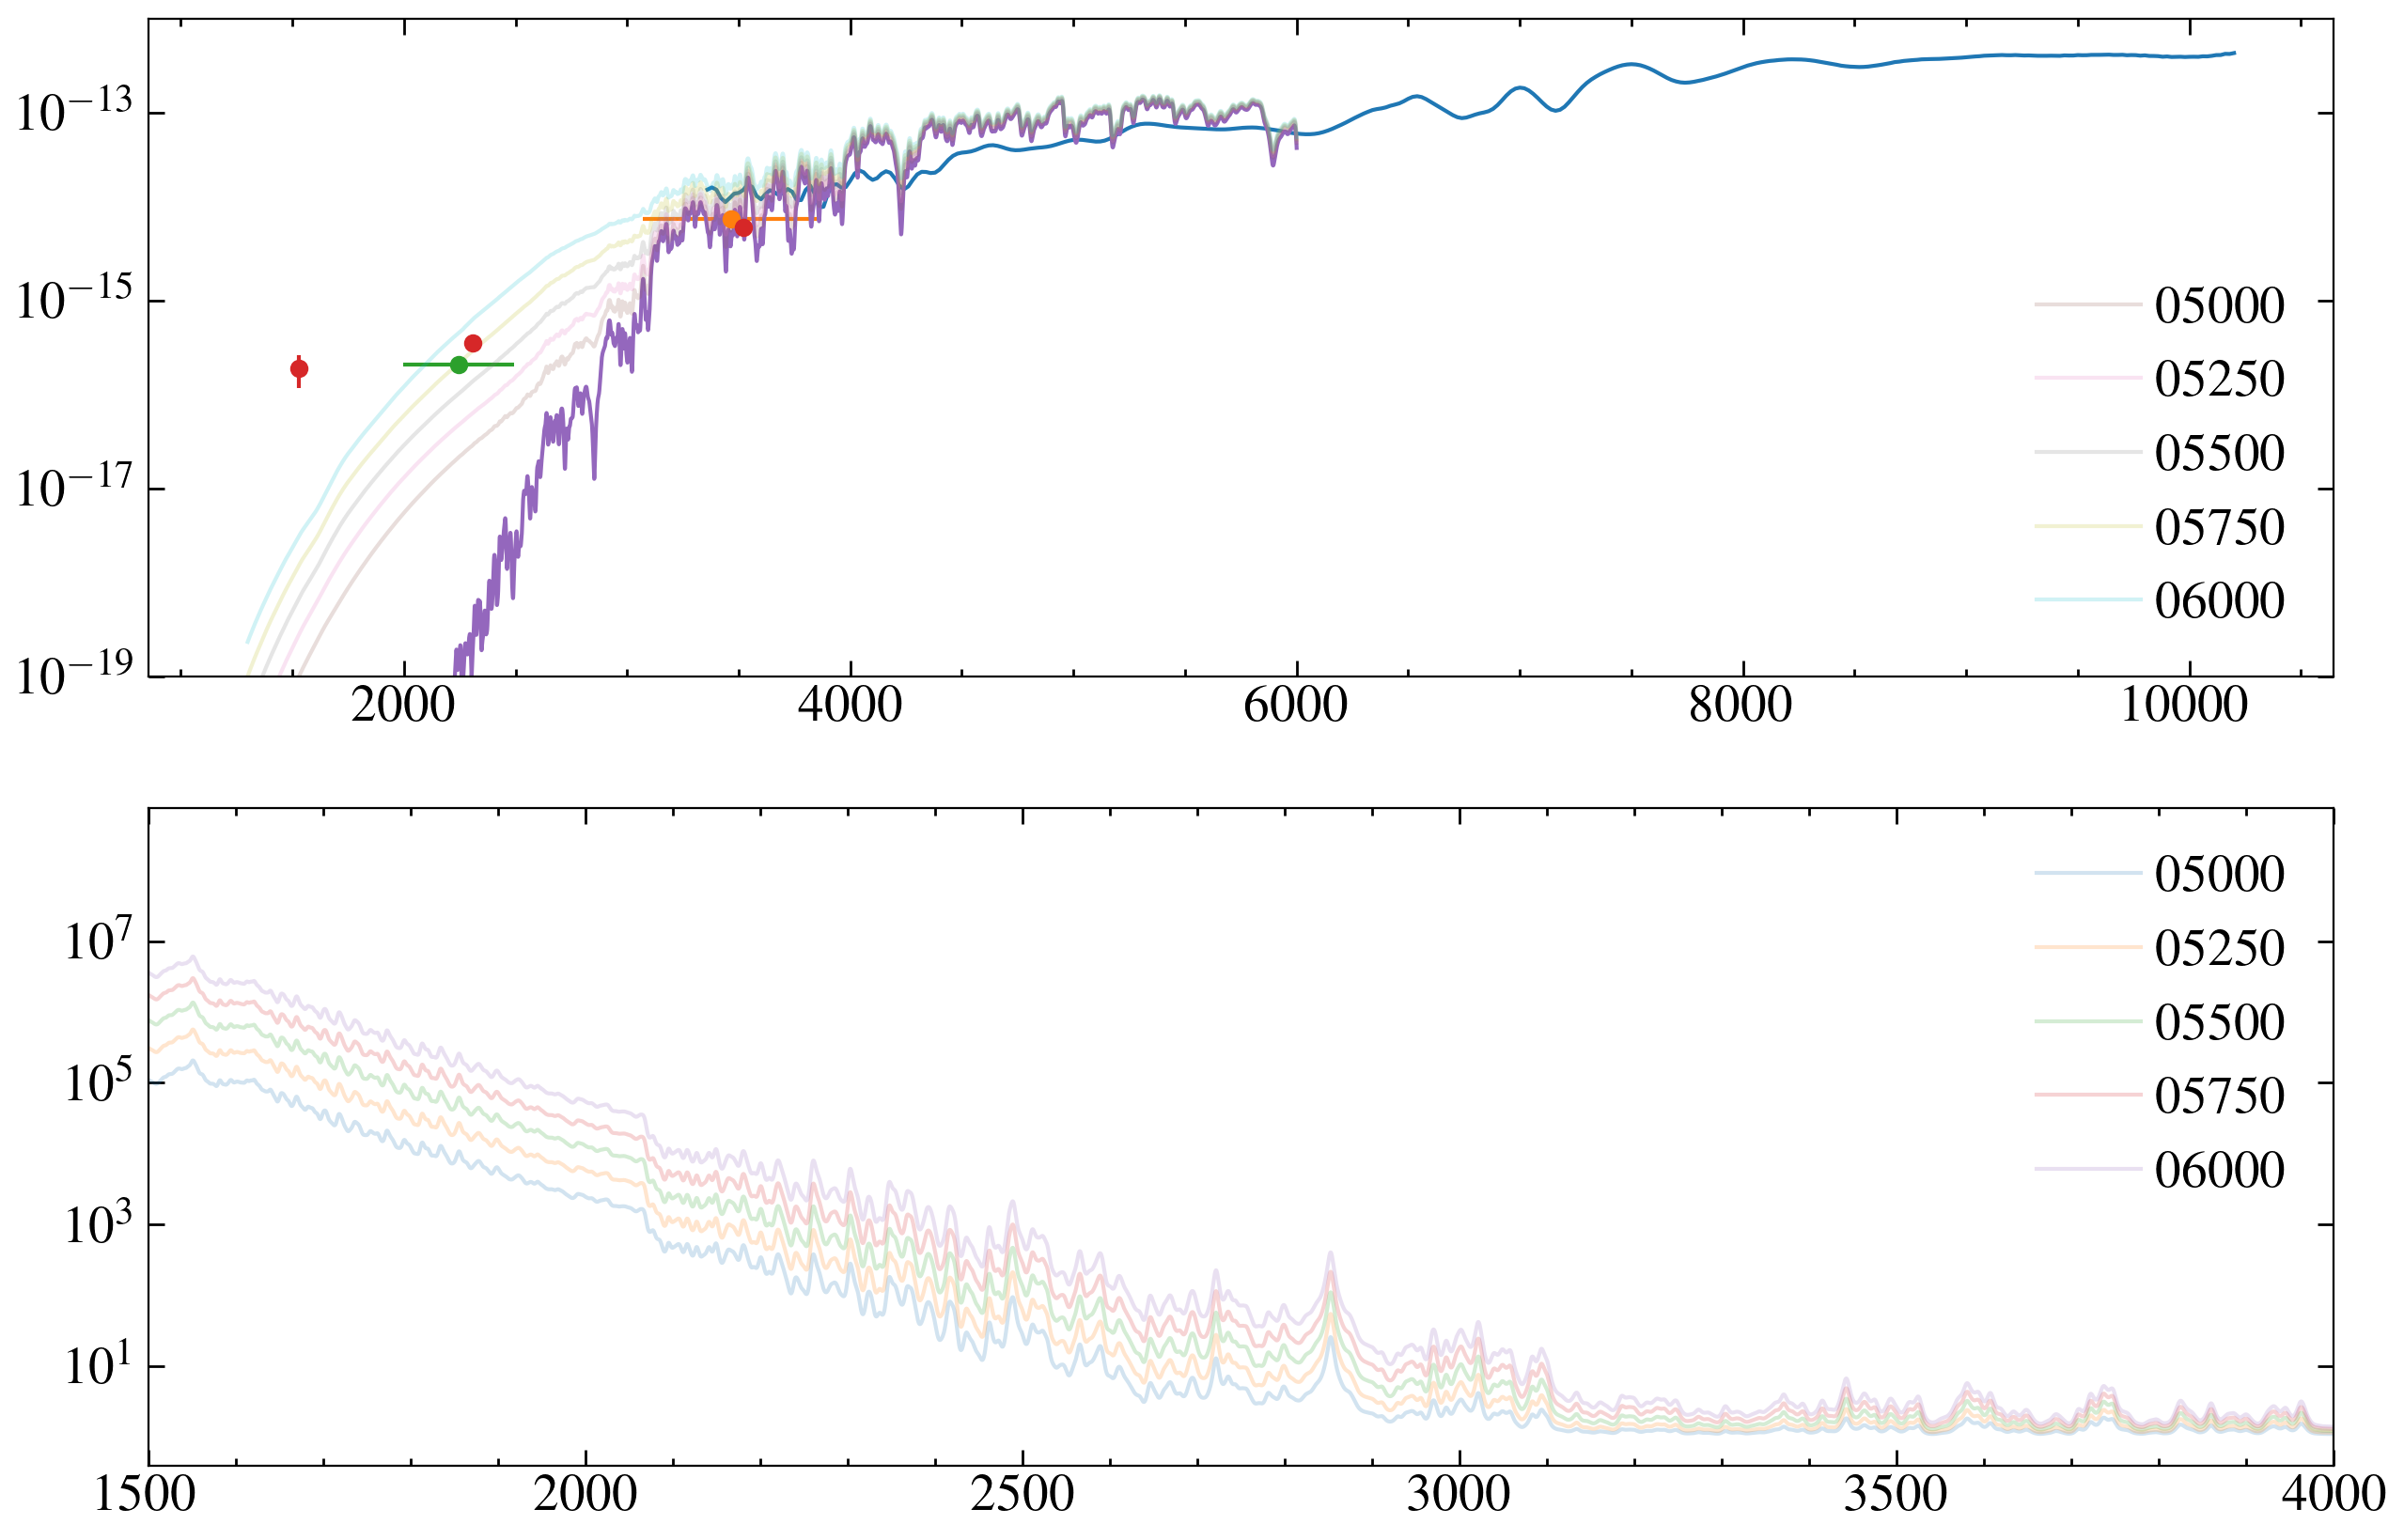

In [36]:
fig, axes = plt.subplots(nrows=2, figsize=(15, 10))
ax = axes[0]
ax.plot(gaia['wavelength']*10, gaia['flux']*(u.W/u.m**2/u.nm).to(u.erg/u.s/u.cm**2/u.AA))

for i, phot in enumerate(ubands[0:1]):
    data = fits.getdata(phot, 1)
    w, fwhm = cenwaves[data['FILTER'][0]], fwhms[data['FILTER'][0]]
    f, e = data['AB_FLUX_AA'], data['AB_FLUX_AA_ERR']
    ax.errorbar(w, f, yerr=e, xerr=fwhm/2, marker='o', ls='none')
    
    print(w, f, e)

uvf = []
uve = []
for i, phot in enumerate(uvbands):
    
    data = fits.getdata(phot, 1)
    w, fwhm = cenwaves[data['FILTER'][0]], fwhms[data['FILTER'][0]]
    f, e = data['AB_FLUX_AA'], data['AB_FLUX_AA_ERR']
    uvf.append(f)
    uve.append(e)
weights = 1/(np.array(uve)**2)
flux = np.average(uvf, weights= weights)
err =  (1 / np.sum(weights))**0.5
# plt.errorbar(w, f, yerr=e, xerr=fwhm/2, marker='o', ls='none', capsize=10)
# print(flux/err)
ax.errorbar(w, flux, yerr=err,xerr=fwhm/2, marker='o', ls='none')
print(w, flux, err)
# print(phot_w.value, phot_f.value, phot_e.value)

ax.errorbar(phot_w, phot_f, yerr=phot_e, marker='o', ls='none')
# ax.plot(dmw1, dmf1*scale)

ax.plot(pwi, pfi)


ax.set_yscale('log')

for model in mods[0:5]:
    tmod = os.path.split(model)[1][2:7]
    mw, mf = np.loadtxt(model, unpack=True)
    wdmask =  (mw > 1300) & (mw < 6000)
    mw, mf = mw[wdmask], mf[wdmask]*wd_scale
    mfi = interp1d(mw, mf, fill_value='extrapolate')(pwi)
    mfi = mfi+pfi
    # mfi = interp1d(mw, mf, fill_value='extrapolate')(dmw1)
    # mfi = mfi+(dmf1*scale)
    
    # ax.plot(dmw1, mfi, alpha=0.2, label = tmod)
    ax.plot(pwi, mfi, alpha=0.2, label = tmod)
    
    
    
    # axes[1].plot(dmw1, mfi/(dmf1*scale), alpha=0.2, label=tmod)
    axes[1].plot(pwi, mfi/pfi, alpha=0.2, label=tmod)

ax.legend()
ax.set_ylim(1e-19, 1e-12)
axes[1].legend()

axes[1].set_yscale('log')
axes[1].set_xlim(1500, 4000)


/tmp/ipykernel_10958/1453756081.py:49: RuntimeWarning: divide by zero encountered in divide
  axes[1].plot(dmw1, mfi/(dmf1*scale), alpha=0.2, label=tmod)


(1500.0, 4000.0)

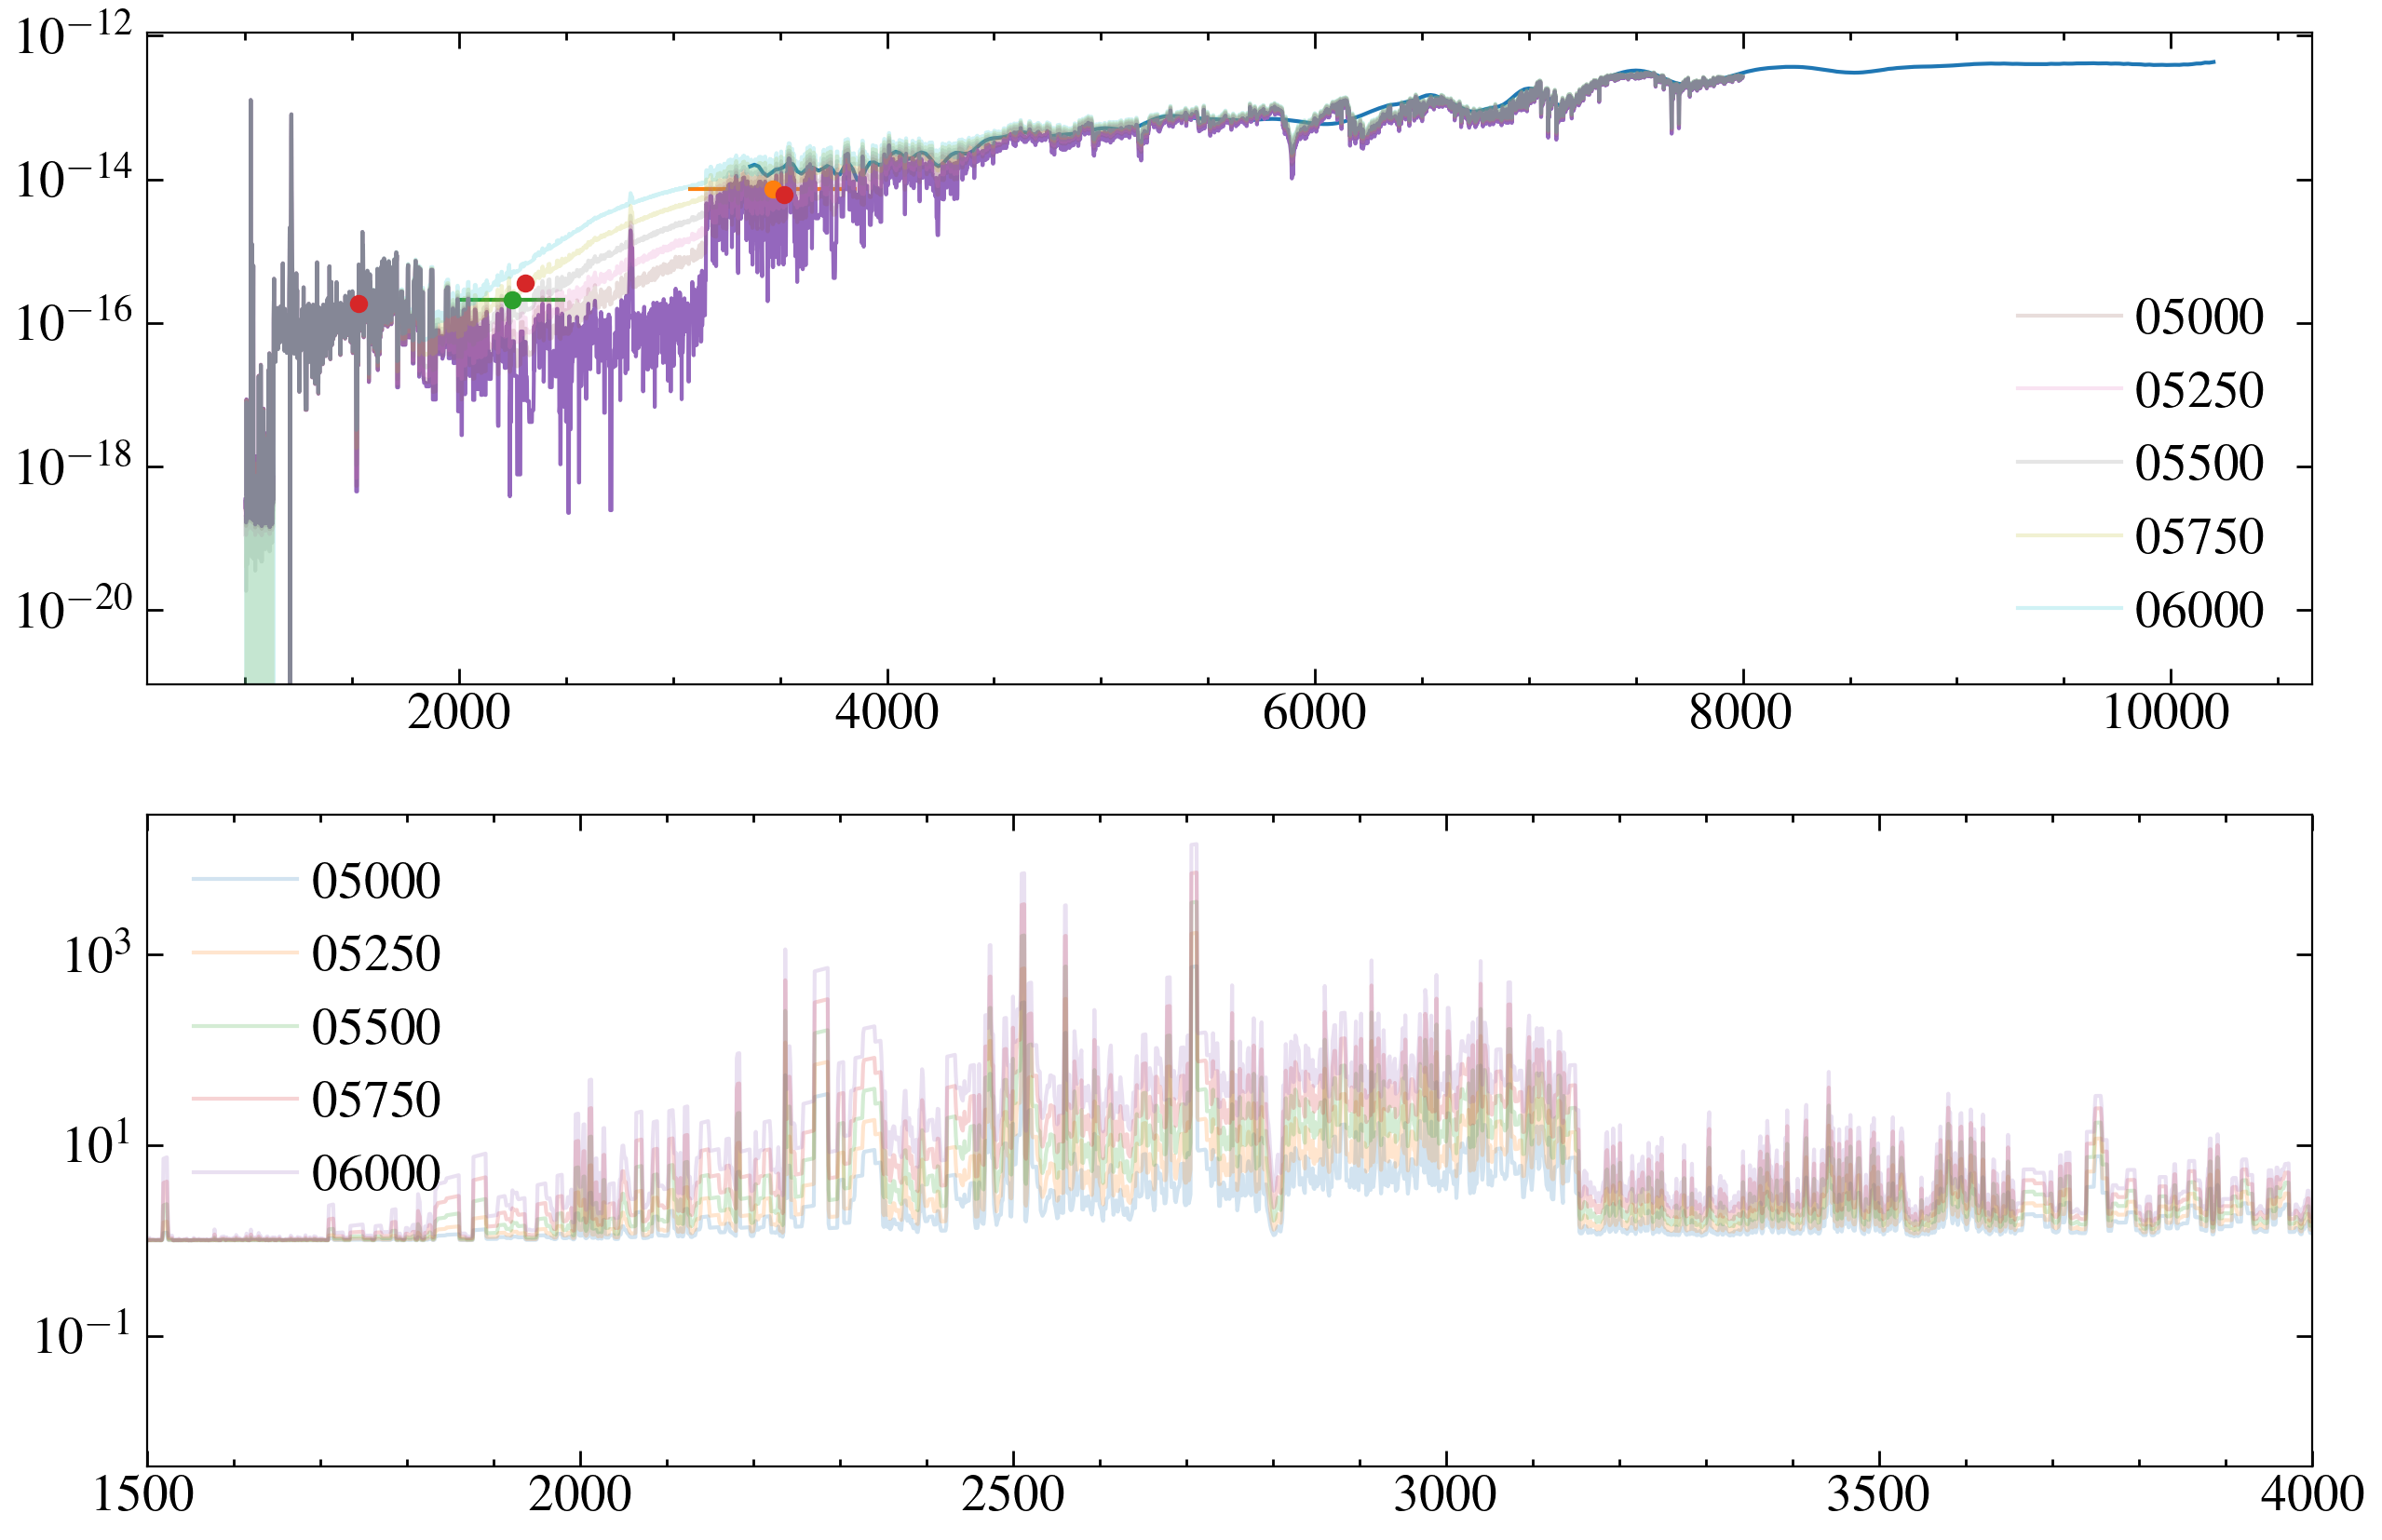

In [37]:
fig, axes = plt.subplots(nrows=2, figsize=(15, 10))
ax = axes[0]
ax.plot(gaia['wavelength']*10, gaia['flux']*(u.W/u.m**2/u.nm).to(u.erg/u.s/u.cm**2/u.AA))

for i, phot in enumerate(ubands[0:1]):
    data = fits.getdata(phot, 1)
    w, fwhm = cenwaves[data['FILTER'][0]], fwhms[data['FILTER'][0]]
    f, e = data['AB_FLUX_AA'], data['AB_FLUX_AA_ERR']
    ax.errorbar(w, f, yerr=e, xerr=fwhm/2, marker='o', ls='none')

uvf = []
uve = []
for i, phot in enumerate(uvbands):
    
    data = fits.getdata(phot, 1)
    w, fwhm = cenwaves[data['FILTER'][0]], fwhms[data['FILTER'][0]]
    f, e = data['AB_FLUX_AA'], data['AB_FLUX_AA_ERR']
    uvf.append(f)
    uve.append(e)
weights = 1/(np.array(uve)**2)
flux = np.average(uvf, weights= weights)
err =  (1 / np.sum(weights))**0.5
# plt.errorbar(w, f, yerr=e, xerr=fwhm/2, marker='o', ls='none', capsize=10)
# print(flux/err)
ax.errorbar(w, flux, yerr=err,xerr=fwhm/2, marker='o', ls='none')
ax.errorbar(phot_w, phot_f, yerr=phot_e, marker='o', ls='none')
ax.plot(dmw1, dmf1*scale)

# ax.plot(pwi, pfi)


ax.set_yscale('log')

for model in mods[0:5]:
    tmod = os.path.split(model)[1][2:7]
    mw, mf = np.loadtxt(model, unpack=True)
    wdmask =  (mw > 1300) & (mw < 6000)
    mw, mf = mw[wdmask], mf[wdmask]*wd_scale
    # mfi = interp1d(mw, mf, fill_value='extrapolate')(pwi)
    # mfi = mfi+pfi
    mfi = interp1d(mw, mf, fill_value='extrapolate')(dmw1)
    mfi = mfi+(dmf1*scale)
    
    ax.plot(dmw1, mfi, alpha=0.2, label = tmod)
    # ax.plot(pwi, mfi, alpha=0.2, label = tmod)
    
    
    
    axes[1].plot(dmw1, mfi/(dmf1*scale), alpha=0.2, label=tmod)
    # axes[1].plot(pwi, mfi/pfi, alpha=0.2, label=tmod)

ax.legend()
axes[1].legend()

axes[1].set_yscale('log')
axes[1].set_xlim(1500, 4000)

So the answer is the same whether we use the proxy or just the PHX model = T WD = 5750K.

In [38]:
#making a new phx model for another star as I have the stuff here

In [39]:
# import prepare_phoenix_svo as pp


# G = const.G
# M = const.M_sun.to(u.kg)
# R = const.R_sun.to(u.m)
# mass = 0.38
# # teff = 5715
# teff = 3430
# # teff_e = 64
# # radius = 1.79
# radius = 0.361
# distance = 1000/2.78
# save_path = '../pceb/tess_proposal/data/'
# star = 'SDSSJ0235'
# g = ((G*mass*M)/(radius*R)**2).to(u.cm/u.s**2)
# repo = '/media/david/2tb_ext_hd/hddata/mega_muscles/data-vacuum/'

# star_params = {'Teff': teff, 'logg': np.log10(g.value), 'FeH': 0.00, 'aM': 0, 'Radius':radius*u.R_sun, 'Distance':distance*u.pc, 'Teff_e':teff_e}
# pw, pf = pp.make_phoenix_spectrum(star, save_path, repo, star_params, save_ecsv=True, plot=False, make_error=False)
# normfac = ((radius*R)/((distance*u.pc).to(u.m)))**2
# print(normfac)

# pdata = Table.read('models/Wasp_63_phoenix_interpolated.ecsv')
# pw, pf, pe = pdata['WAVELENGTH'], pdata['FLUX'], pdata['ERROR']

In [40]:
tic = 219085795
star = lk.search_lightcurve('TIC219085795')
star

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 26,2020,SPOC,120,219085795,0.0
1,TESS Sector 25,2020,SPOC,120,219085795,0.0
2,TESS Sector 24,2020,SPOC,120,219085795,0.0
3,TESS Sector 53,2022,SPOC,20,219085795,0.0
4,TESS Sector 52,2022,SPOC,20,219085795,0.0
5,TESS Sector 51,2022,SPOC,20,219085795,0.0
6,TESS Sector 53,2022,SPOC,120,219085795,0.0
7,TESS Sector 52,2022,SPOC,120,219085795,0.0
8,TESS Sector 51,2022,SPOC,120,219085795,0.0


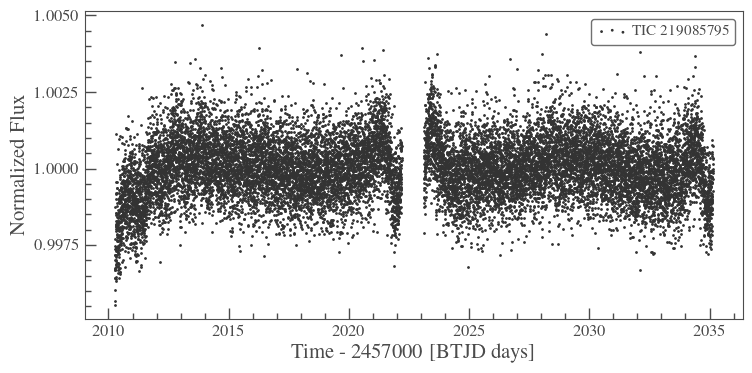

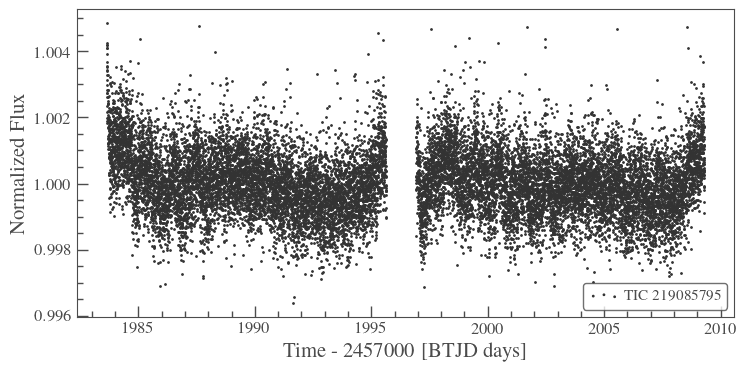

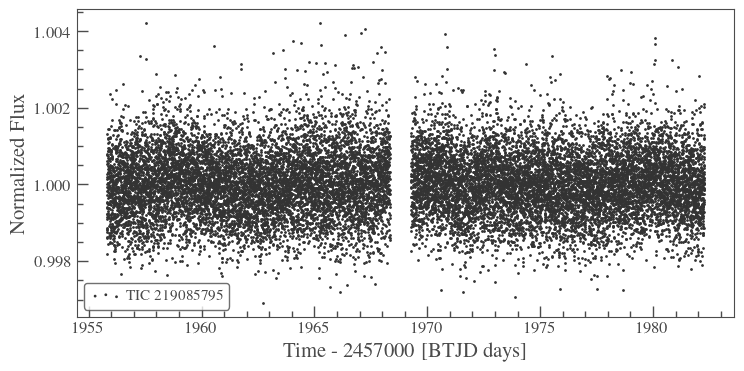

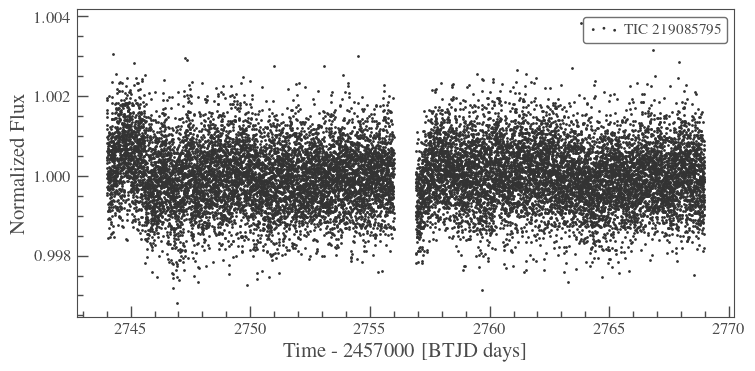

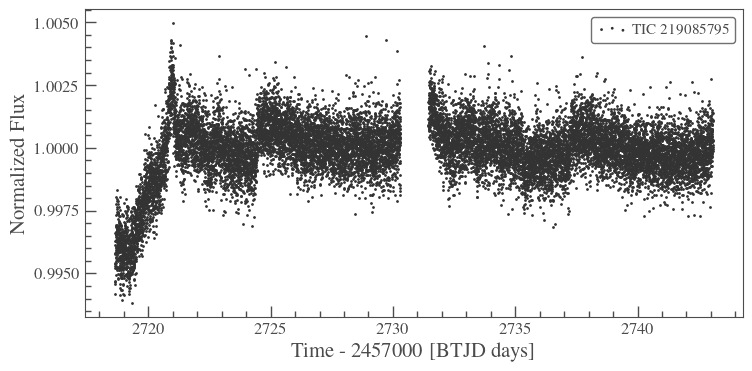

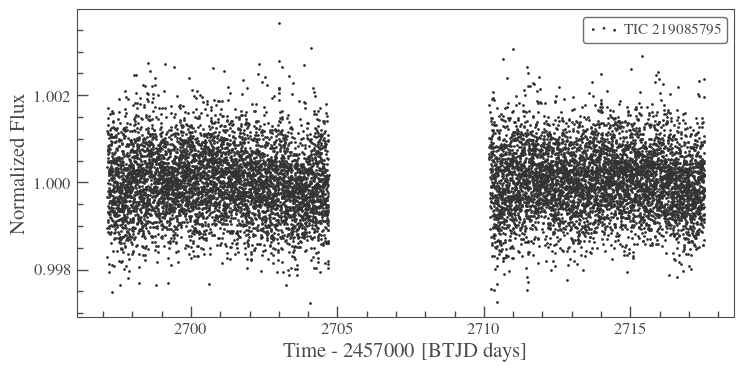

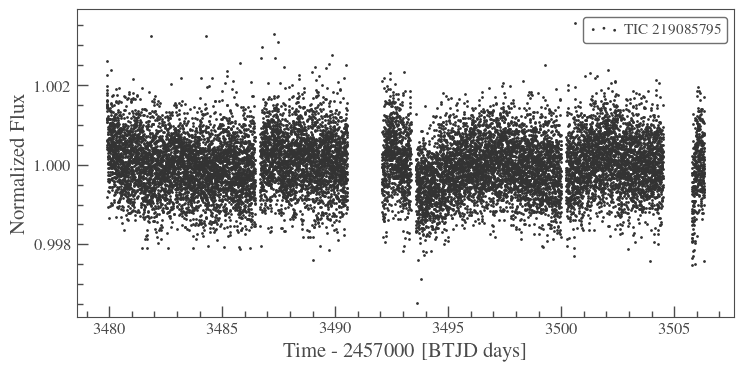

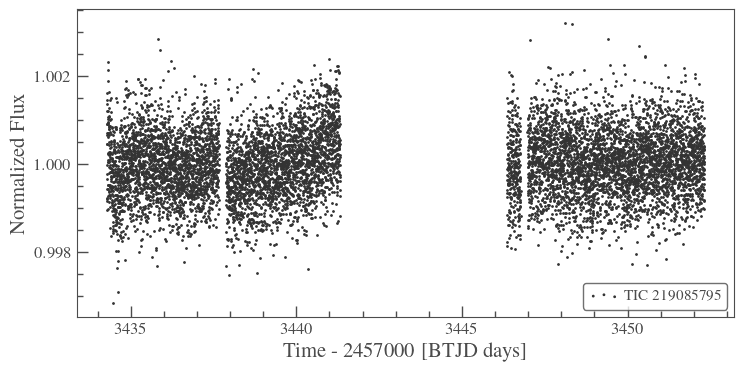

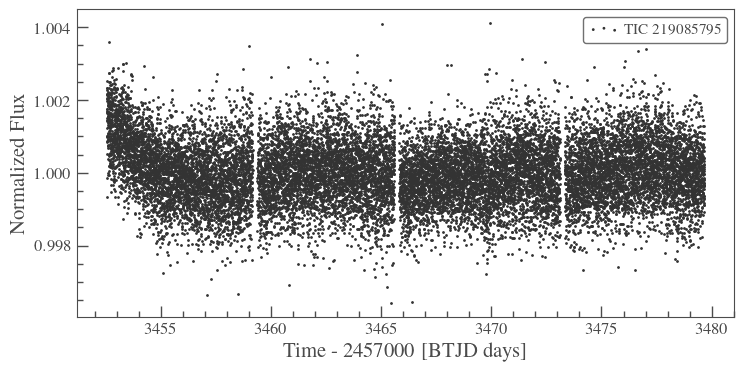

In [41]:
for sr in star:
    # print(sr)
    if sr.exptime == 120*u.s and sr.author=='SPOC':
        lc = sr.download(download_dir='data/')
        lc = lc.normalize().remove_outliers()
        lc.scatter()

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

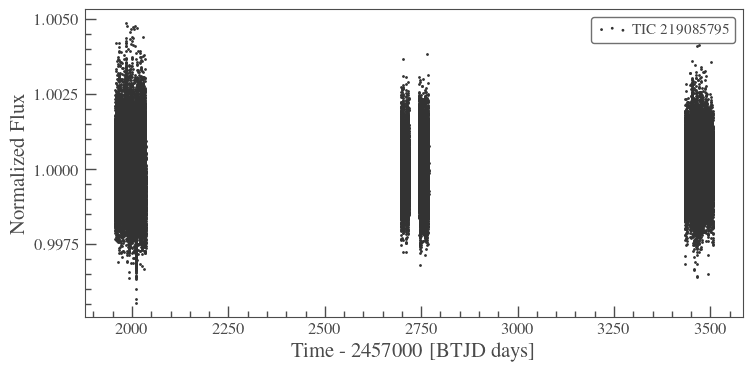

In [42]:
n = 0
for sr in star:
    if sr.exptime == 120*u.s and sr.author=='SPOC' and sr.mission != 'TESS Sector 52':
        lci = sr.download(download_dir='data/')
        lci = lci.remove_outliers().normalize().remove_nans()
        if n == 0:
            lc = lci
        else:
            lc = lc.append(lci)
        n +=1
lc.scatter()

In [43]:
porb = 14.7136*u.d

In [44]:
pg = lc.to_periodogram(oversample_factor=1,minimum_period=1*u.day, maximum_period=100*u.day)
# pg = lc.to_periodogram(method='bls', minimum_period=1, maximum_period=20)
print(pg.period_at_max_power)

15.19644330086703 d


<Axes: xlabel='Period [$\\mathrm{d}$]', ylabel='Power'>

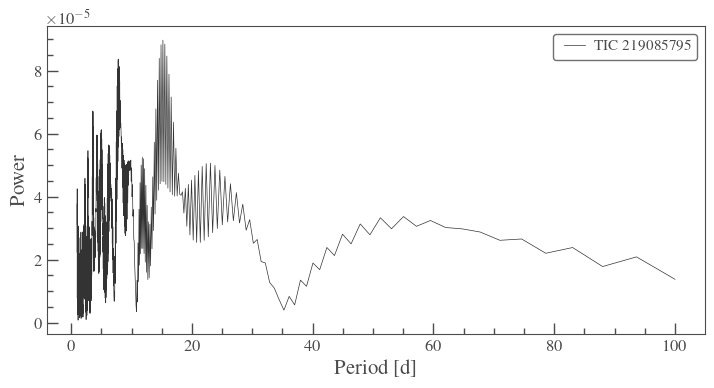

In [45]:
pg.plot()

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

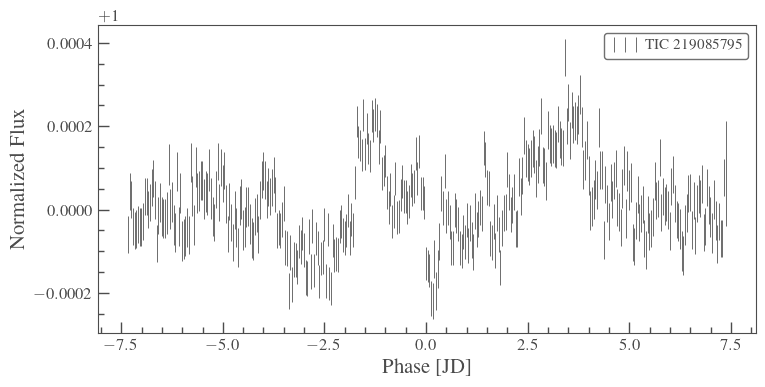

In [46]:
lcf = lc.fold(porb).bin(1*u.hr)
lcf.errorbar()

Can we detect a Mg ii line? No

In [47]:
# lpath = '/media/david/2tb_ext_hd/hddata/mega_muscles/swift_images/l980-5/'
# ims = glob.glob('{}0*/uvot/products/*sk.img.gz'.format(lpath))
# for im in ims:
#     print(im)
#     print(fits.getheader(im, 1)['FILTER'])

Have to do a better job with TESS. ZTF?

In [48]:
ztf = Table.read('data/ztf/g203-47_ztf_lc.fits')

In [81]:
print(np.unique(ztf['filtercode']))
print(np.median(ztf['mag']))


filtercode
----------
        zg
12.436845


1300.6775000000052


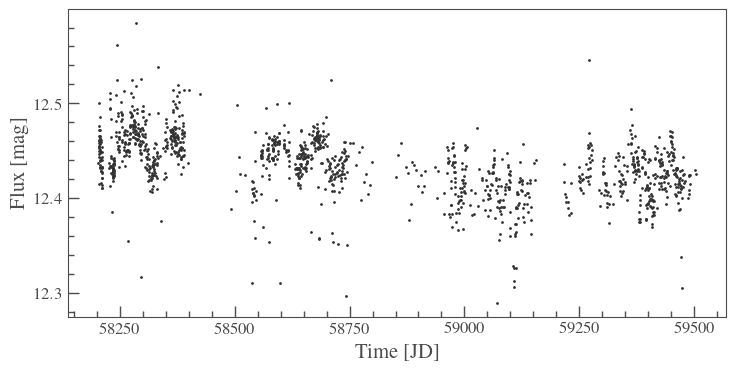

In [76]:
ztflc = lk.LightCurve(time= ztf['mjd'], flux = https://cos.colorado.edu/~kevinf/muscles.html).remove_outliers(sigma=5)
ztflc.scatter()
print(ztf['mjd'][-1] -ztf['mjd'][0])

97.04095326647833 d 6.59532359629719


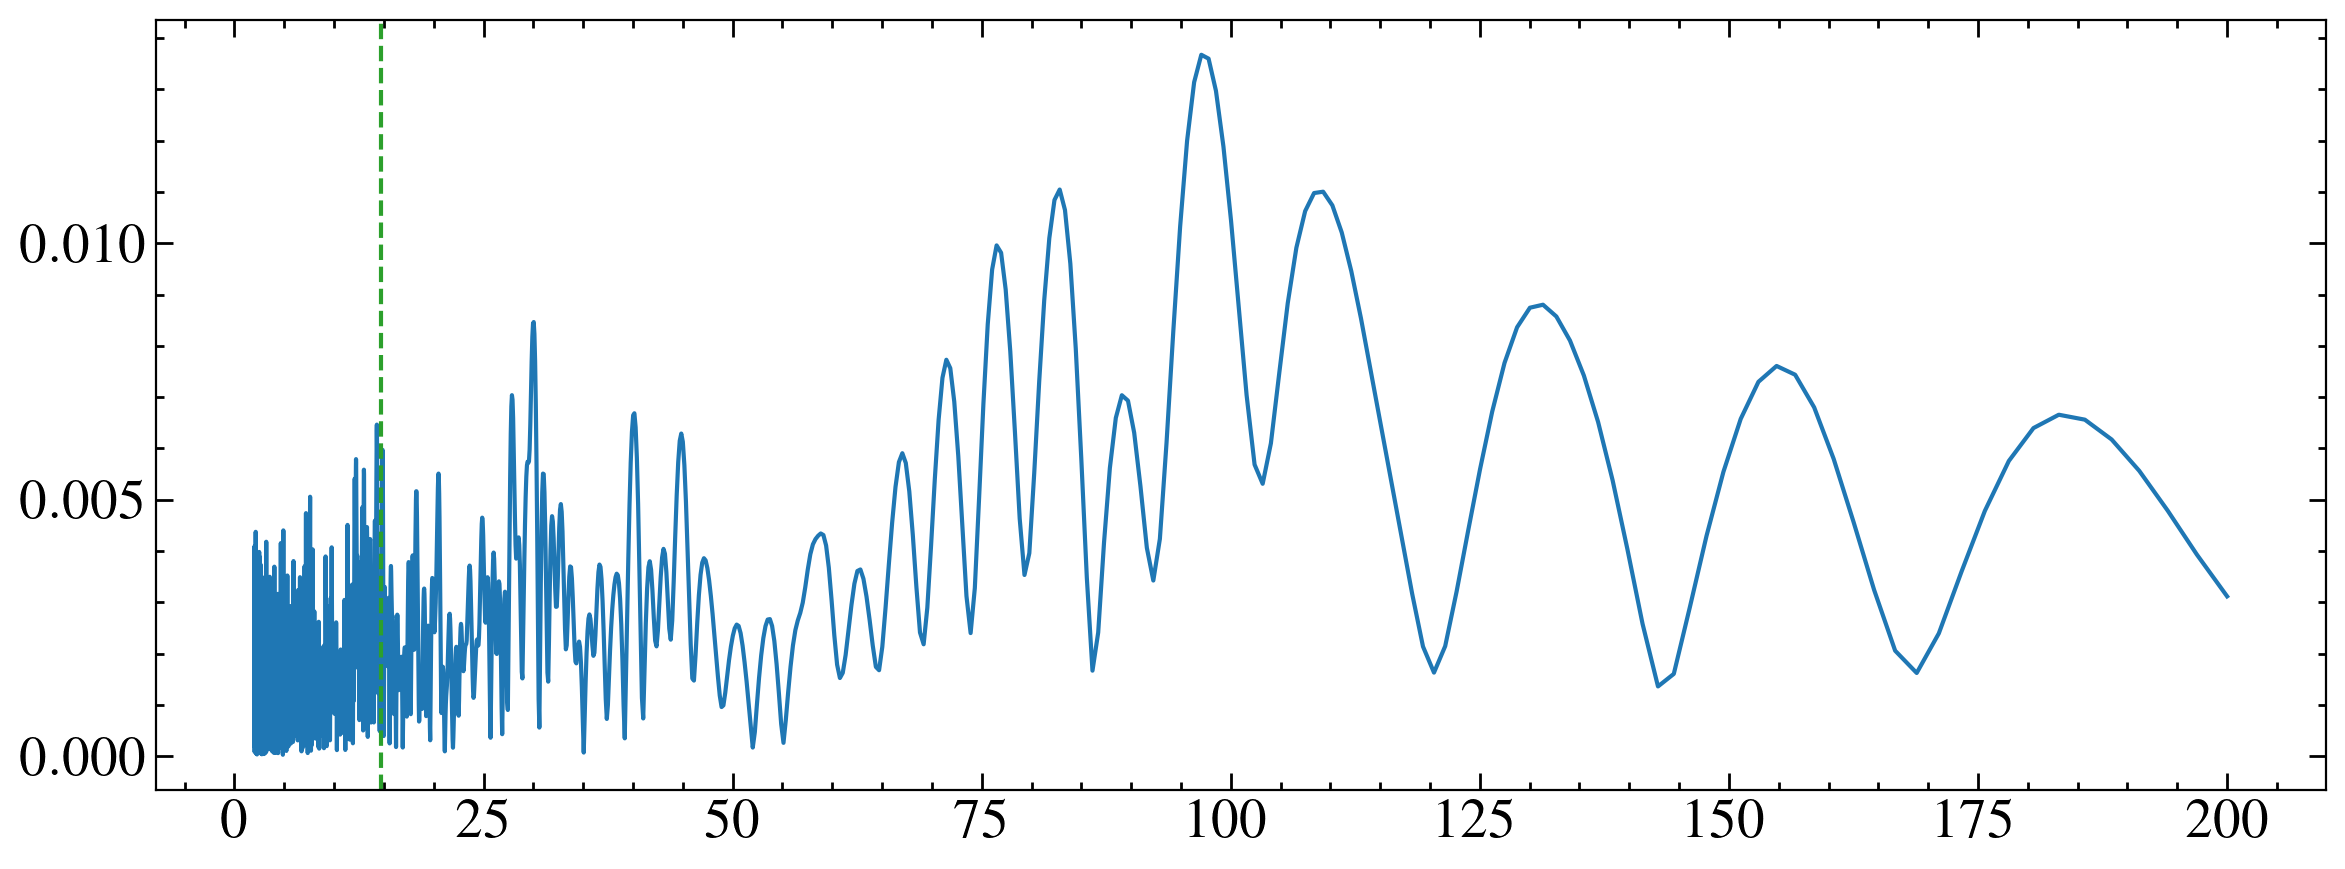

In [71]:
zpg = ztflc.to_periodogram(oversample_factor=10,minimum_period=2*u.d, maximum_period=200*u.day)
# zpg.plot()
fig, ax = plt.subplots()
ax.plot(zpg.period, zpg.power)
ax.axvline(porb.value, ls='--', c='C2')

pmax = zpg.period_at_max_power
print(pmax, pmax/porb)

<Axes: xlabel='Phase [JD]', ylabel='Flux [$\\mathrm{mag}$]'>

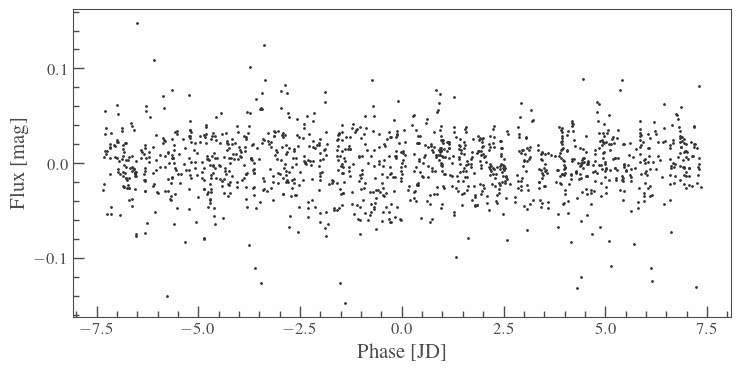

In [75]:
zlcf = ztflc.fold(porb)#.bin(0.3*u.d)
zlcf.scatter()

Nope. Got some Mearth data

In [52]:
mpath = 'data/mearth/LSPMJ1709+4340_tel06_2011-2022.txt'
mt, mf, me = np.loadtxt(mpath, usecols=(0,1, 2), unpack=True)

478.47567099984735
2459158.572187


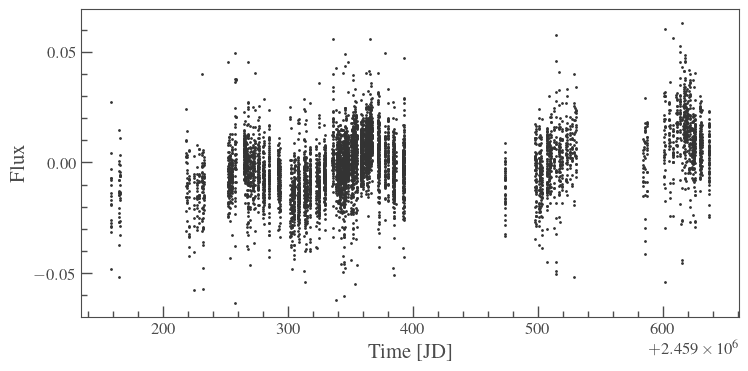

In [53]:
mlc = lk.LightCurve(time= mt, flux = mf, flux_err=me).remove_outliers()
mlc.scatter()
print(mt[-1]- mt[0])
print(mt[0])

<Axes: xlabel='Period [$\\mathrm{d}$]', ylabel='Power'>

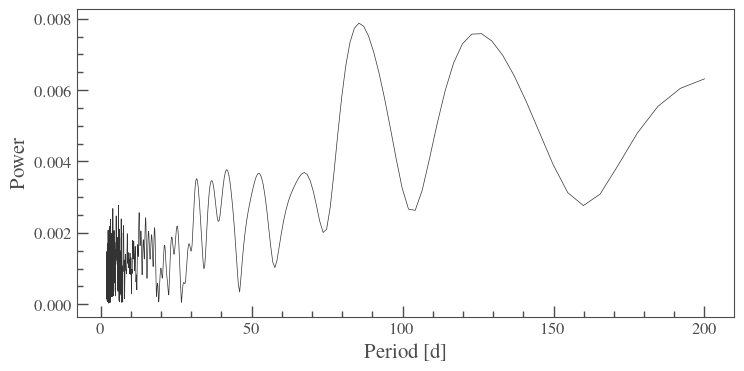

In [54]:
mpg = mlc.to_periodogram(oversample_factor=10,minimum_period=2*u.d, maximum_period=200*u.day)

mpg.plot()

<Axes: xlabel='Phase [JD]', ylabel='Flux'>

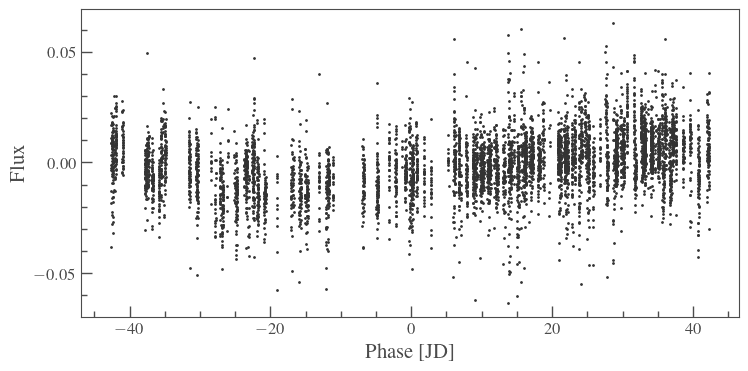

In [55]:
mpf = mlc.fold(mpg.period_at_max_power)#.bin(0.1*u.d)
mpf.scatter()

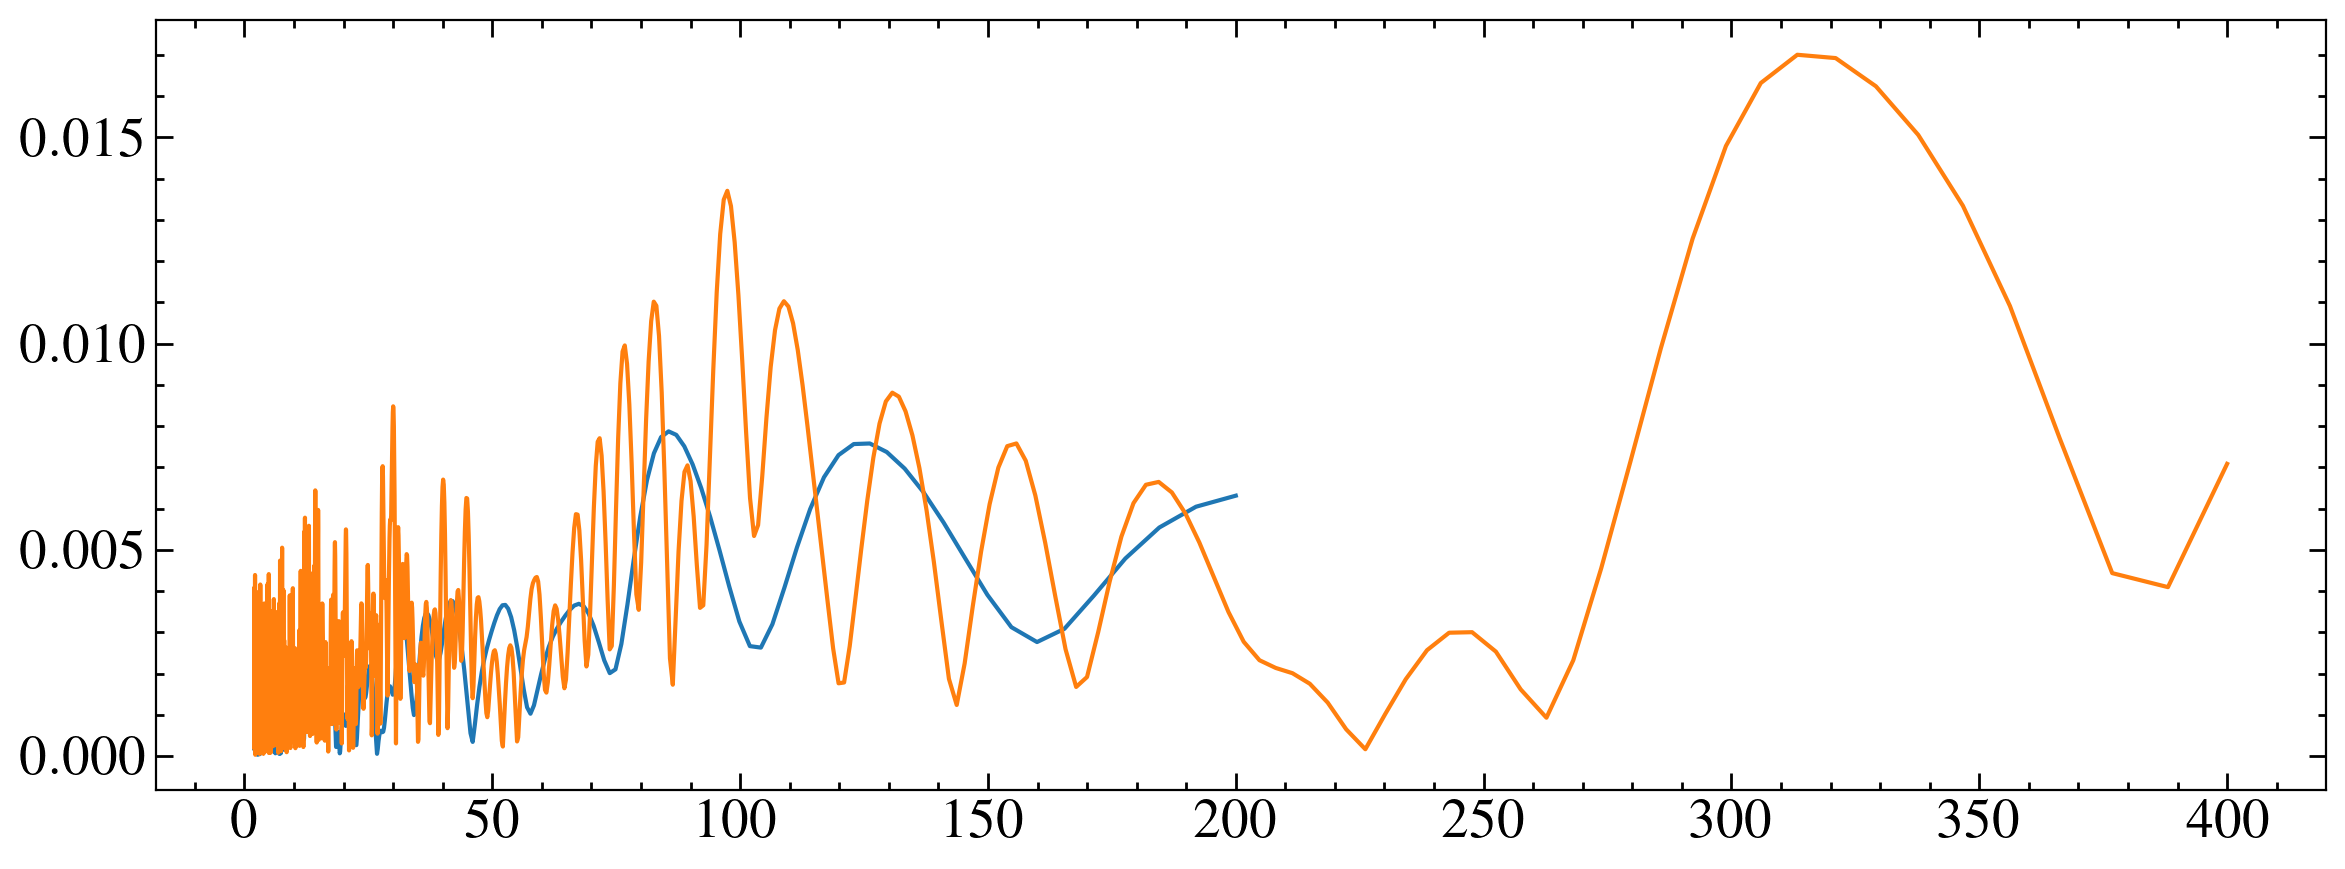

In [56]:
fig, ax = plt.subplots()
ax.plot(mpg.period, mpg.power)
ax.plot(zpg.period, zpg.power)

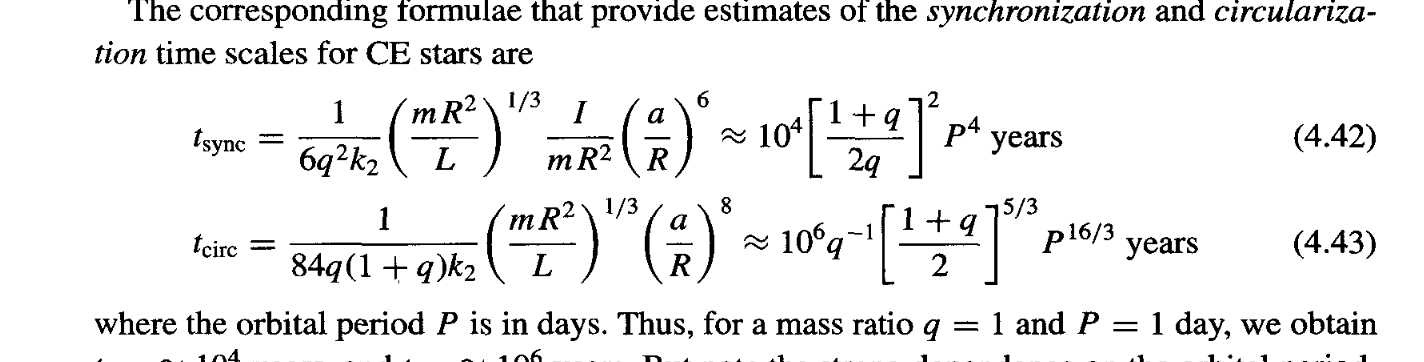
https://ui.adsabs.harvard.edu/abs/2001icbs.book.....H/abstract

1.054528445411582 Gyr
2092.3442636226287 Gyr
1984.151563408977


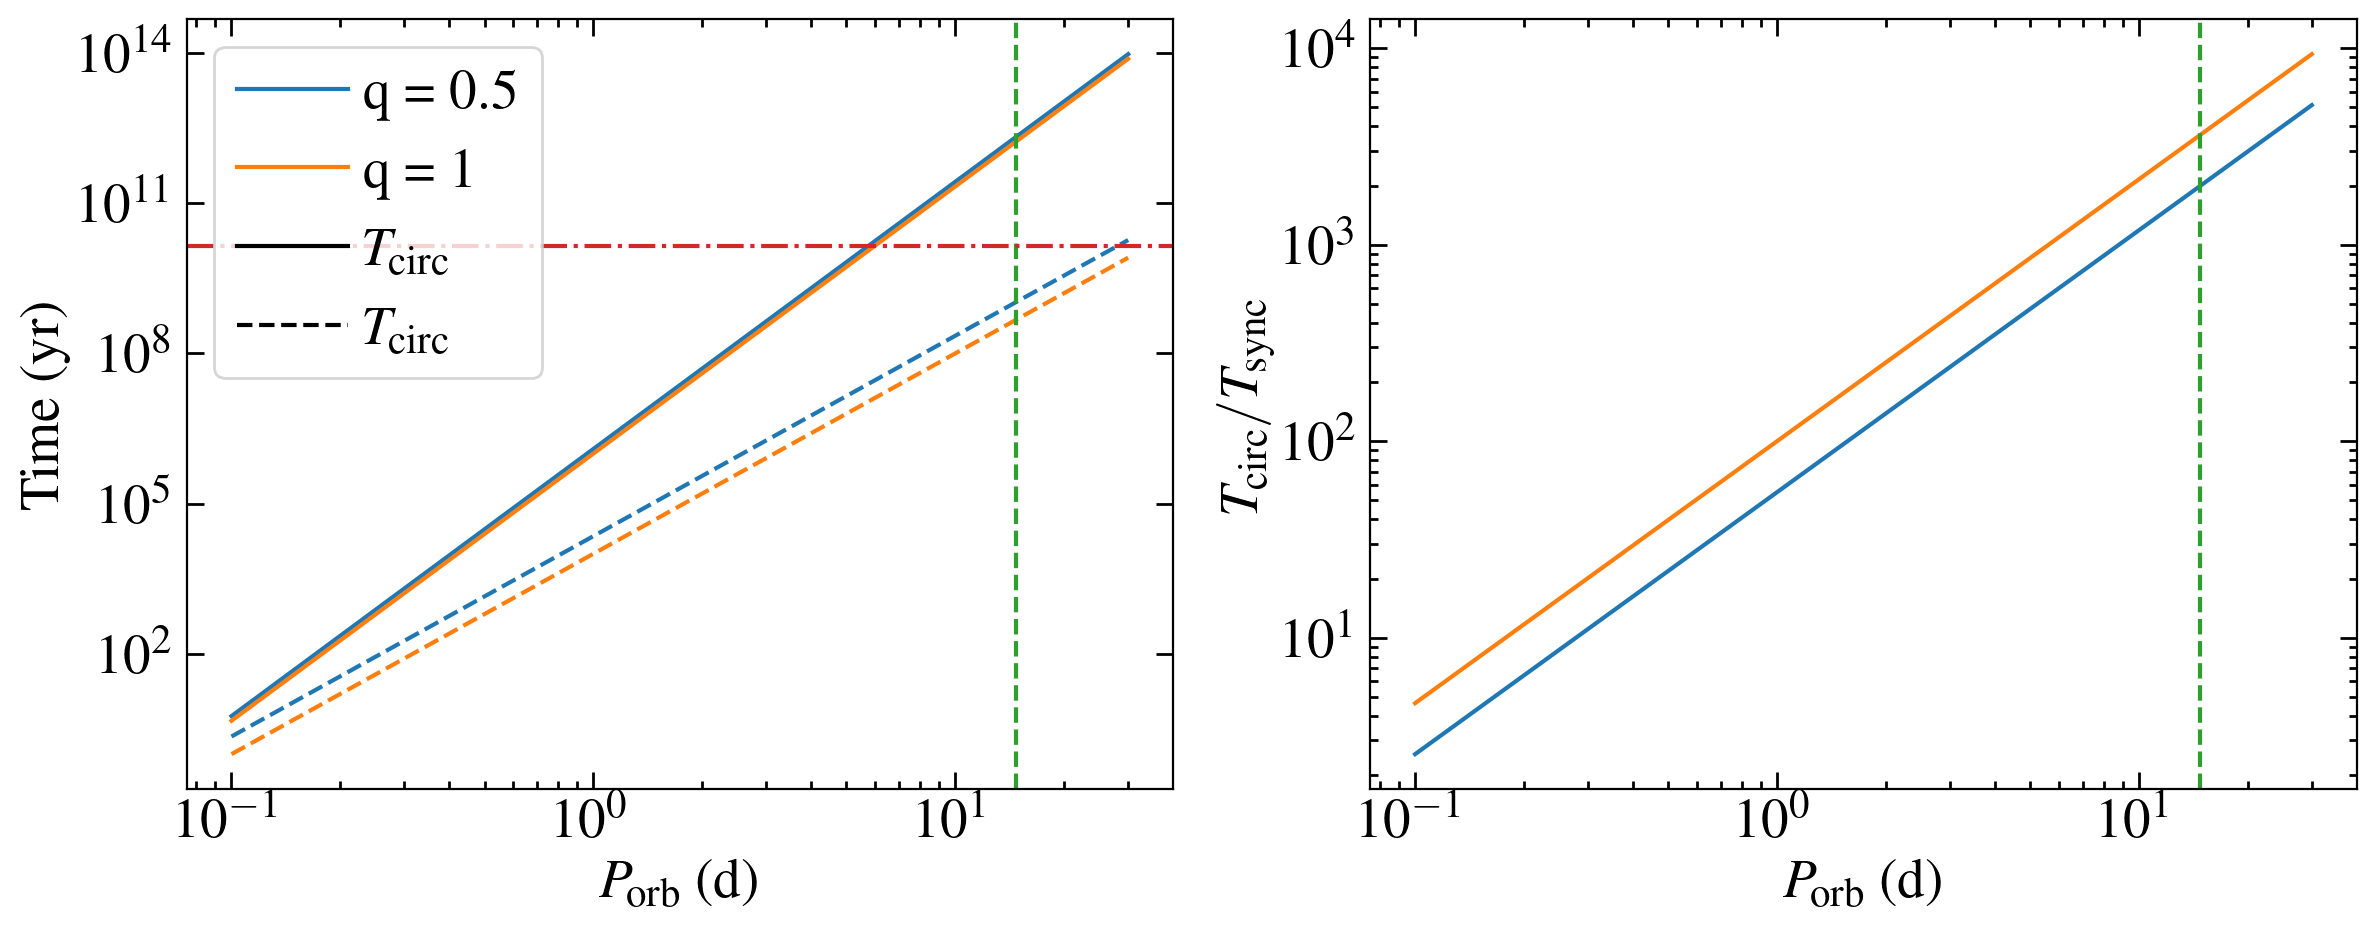

In [57]:
q = 0.5 #ish
p = porb
tsync = (1e4*((1+q)/(2*q))**2) * (p**4)*u.yr/u.d**4
print(tsync.to(u.Gyr))
tcirc = 1e6*(1/q)*((1+q)/2)**(5/3)*(p**(16/3))*u.yr/u.d**(16/3)
print(tcirc.to(u.Gyr))

print(tcirc/tsync)


def tidal_times(q, p):
    tcirc = 1e6*(1/q)*((1+q)/2)**(5/3)*(p**(16/3))*u.yr/u.d**(16/3)
    tsync = (1e4*((1+q)/(2*q))**2) * (p**4)*u.yr/u.d**4
    return tcirc, tsync
    


fig, axes = plt.subplots(ncols =2)

ps = np.linspace(0.1, 30, 200)*u.d
qs = (0.5, 1)

# cols = ['C0', 'C]
for i, q in enumerate(qs):
    tc = []
    ts = []
    for p in ps:
        tci, tsi = tidal_times(q, p)
        tc.append(tci.value)
        ts.append(tsi.value)
    tc, ts = np.array(tc), np.array(ts)
    axes[0].plot(ps, tc, c='C{}'.format(i), label = 'q = {}'.format(q))
    axes[0].plot(ps, ts, ls='--', c='C{}'.format(i))

    axes[1].plot(ps, tc/ts,c='C{}'.format(i))
    axes[i].set_xlabel(r'$P_{\mathrm{orb}}$ (d)')


axes[0].plot([0,0], [0,0], c='k', label = r'$T_{\mathrm{circ}}$')
axes[0].plot([0,0], [0,0], c='k', ls='--', label = r'$T_{\mathrm{circ}}$')

axes[0].set_yscale('log')
axes[1].set_yscale('log')

axes[0].set_xscale('log')
axes[1].set_xscale('log')

axes[0].set_ylabel(r'Time (yr)')
axes[1].set_ylabel(r'$T_{\mathrm{circ}}/T_{\mathrm{sync}}$')

axes[0].legend(frameon=True)    

[axes[i].axvline(porb.value, ls= '--', c='C2') for i in range(2)]
axes[0].axhline(13.8e9, ls = '-.', c='C3')

tcool= 1.8Gyr So it should have time to have lock but not circularlise, instead we see the opposite?

https://ui.adsabs.harvard.edu/abs/2018MNRAS.475.1960F/abstract has an upper limit on vrot. No, misread, not resloved.Not helpful.  

https://iopscience.iop.org/article/10.3847/1538-4357/834/1/85 has L halpha, also puts it low  

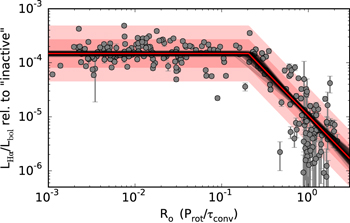

 140-145 F6.3   [10-4]   logLHa   ?="" log LH{alpha}/Lbol x 10-4 relative to "quiescent" level. Not sure what the log is doing, doesn't make sense with the rest of the paper

In [58]:
# hatab = fits.open('misc/halpha_tab.fit')
# hadata = hatab[1].data 
# hatab[1].data.names
# hadata.close()

# fig, ax = plt.subplots()

# ax.scatter(np.arange(len(hadata)), abs(hadata['logLHa'])*1e-4)
# ax.set_yscale('log')
# # ax.set_xscale('log')

In [59]:
# hadata['Per']

In [60]:
vsini = -2*u.km/u.s
rstar = 0.286*u.Rsun
plim = (2*np.pi*rstar.to(u.km)) / ((abs(vsini))) 
print(plim.to(u.d))

vporb = (2*np.pi*rstar.to(u.km)) / (porb.to(u.s)) 
print(vporb)

7.234760631982543 d
0.9834113516722682 km / s


1.0459105593270919 1.0440643383468746 0.0764981106626591
285.755466751649
20.900212855764046
0.07314020303215577


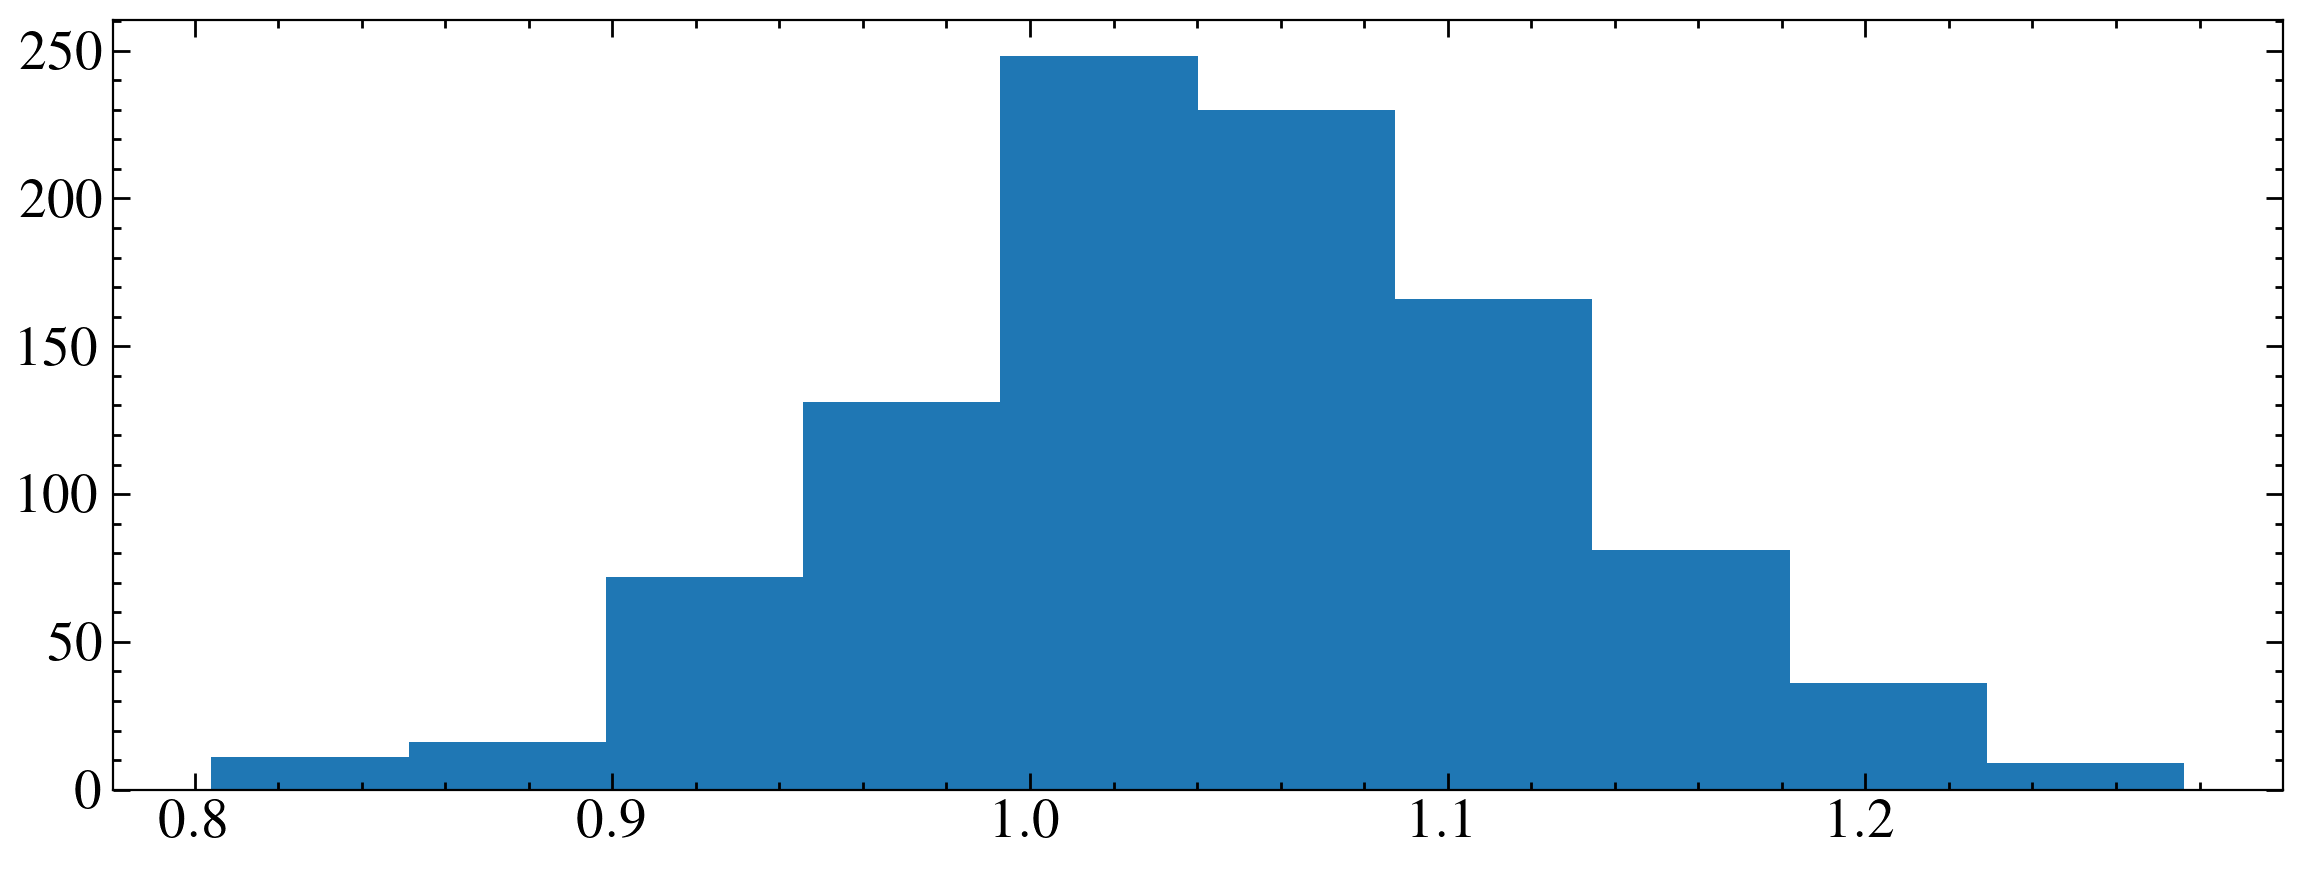

In [61]:
# 2.827612103327233e-05

# c = (1.49e-4)* 0.21**2.3
# print(c*0.63**-2.3)
# print((2.8e-5/c)**(1/-2.3))

tau = 10**2.4365


rsat, rsat_e = 0.21, 0.02
lsat, lsat_e = 1.49e-4,0.08e-4
# print(lsat, lsat_e)
b, be = -1.7, 0.1

n=1000
rs = np.random.normal(rsat, rsat_e, n)
ls = np.random.normal(lsat, lsat_e, n)
bs = np.random.normal(b, be, n)

rout = []
hain = 0.095e-4
for i in range(n):
    ri, li, bi = rs[i], ls[i], bs[i]
    c = li * (ri ** (-1*b))
    rout.append((hain/c)**(1/-2.3))

rout = np.array(rout)
rout = rout[np.isnan(rout)==False]
plt.hist(rout)
print(np.mean(rout), np.median(rout), np.std(rout))

print(np.mean(rout)*tau)
print(np.std(rout)*tau)
print((np.std(rout)*tau)/(np.mean(rout)*tau))

# ha =0.286*1e-4
# print(ha)

In [62]:
c = 1.49*0.21**1.7
c

0.10494435180836859

In [63]:
ro = 1
pg = ro*(10**2)
pg
# ro*

100

In [64]:
# xmm preditction
# for swift upper limit

cr = (1.29e-1+2*2.2e-2)*0.7
print(250/cr)

#for 0.1*upper limit

crl = (1e-2+(2*2e-4))*0.7
print(250/crl)

2064.4095788604463
34340.659340659346


In [65]:
gra, gdec=	257.381431585184,  43.6813257952583 

In [66]:
elist = Table.read('/home/david/work/gPhoton2/wdcat_eclipse_list.csv')

In [67]:
dis = (abs(gra-elist['ra'])**2+abs(gdec-elist['dec'])**2)**0.5
arg = np.argmin(dis)
print(elist[arg])

eclipse        ra              dec      
------- ---------------- ---------------
   5606 255.124824726751 42.414695279851


That didn't work. Maybe

In [68]:
glists = glob.glob('/home/david/work/gPhoton2/test_data/e21711/*movie-photom*.csv')
# glist
# for glist in glists:
#     fig, ax = plt.subplots()
#     glist = Table.read(glist)


#     ax.scatter(glist['ra'], glist['dec'])
#     ax.scatter(gra, gdec)
glist = Table.read(glists[0])
glist

# plt.hist(glist['mag'])

id,xcentroid,ycentroid,sharpness,roundness1,roundness2,npix,sky,peak,flux,mag,xcenter,ycenter,aperture_sum,aperture_sum_mask,aperture_sum_edge,ra,dec,aperture_sum_0,aperture_sum_1,aperture_sum_2,aperture_sum_flag_0,aperture_sum_flag_1,aperture_sum_flag_2,aperture_sum_edge_0,aperture_sum_edge_1,aperture_sum_edge_2
int64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,1354.0105785810515,22.73148974910736,0.9606385582340509,-0.17288922,-0.2025741832901131,49,0.0,0.02229345217347145,2.530951738357544,-1.0082096596510273,1354.0105785810515,22.73148974910736,40.06440529289911,0.0,30.18184749571739,257.4626938479261,43.13425924823941,30.525512599241715,9.538892812866688,0.0,0.0,0.0,0.0,23.971501663295875,7.210345832421512,0.0
2,1582.467598574344,27.42287720084324,0.7963409362149627,-0.6736426,-0.4283779613815912,49,0.0,0.02230052277445793,2.708686113357544,-1.081896703119192,1582.467598574344,27.42287720084324,50.72453075912116,0.0,37.59209386691153,257.3322580321621,43.136237283563375,33.125723872833944,17.598806886287214,0.0,0.0,0.0,0.0,25.620871107463966,11.97122275944757,0.0
3,1585.9643824186396,31.645257797892473,0.7743963246131326,-0.31196508,-0.5046433902891523,49,0.0,0.022281352430582047,2.948796510696411,-1.1741120099393014,1585.9643824186396,31.645257797892473,61.02834699417788,0.0,44.45237902866508,257.33026017403694,43.13799561671639,31.28510796832424,25.70771491625674,4.035524246072271,0.0,0.0,0.0,24.733847878286902,17.94851517336011,2.914854396762734
4,1436.9702429394565,32.801263105635414,0.9034486550743328,-0.072104596,0.4107582400080251,49,0.0,0.022054104134440422,2.6413893699645996,-1.0545810643224387,1436.9702429394565,32.801263105635414,61.39698561508328,0.0,43.143331767624616,257.41533188194995,43.13848017795821,32.70395441171356,24.817150008301354,3.8758811950683594,0.0,0.0,0.0,22.947554104270036,19.195777663354583,3.0
5,1598.8706296852583,35.243570467986956,0.7519758679167345,-0.31552115,0.4417665151807437,49,0.0,0.025656292214989662,3.4208271503448486,-1.3353278261028703,1598.8706296852583,35.243570467986956,48.112018354642835,0.9421576347066586,35.7607995720068,257.32288974341805,43.13949152197193,16.562468381453108,26.44158496449488,5.107965008694844,0.9421576347066586,0.0,0.0,12.751995295232884,19.356505714894354,3.652298561879568
6,1388.8401759519568,36.31249094643039,0.7634828102082918,0.03930172,0.39108161476943054,49,0.0,0.022974185645580292,3.0959761142730713,-1.2269940035095201,1388.8401759519568,36.31249094643039,57.887142796617425,0.0,39.2025560216747,257.4428145749582,43.139930507604795,29.893266318989667,22.882055541424755,5.111820816993713,0.0,0.0,0.0,21.406935069057617,16.795620952617092,4.0
7,1461.5421195671206,36.56878141796234,0.7551200527212328,0.099413104,0.5666027675844514,49,0.0,0.02104705572128296,2.9145565032958984,-1.1614311980593595,1461.5421195671206,36.56878141796234,53.51321667162763,0.0,40.434770495709856,257.4013025684988,43.140053653512766,24.279234851148487,18.57871764972627,10.655264289962163,0.0,0.0,0.0,18.902973262991956,14.842246748266914,7.689550484450983
8,1527.155492881857,37.79427135216707,0.9124599558072045,0.15641813,0.8263733155939258,49,0.0,0.022292159497737885,2.50368070602417,-0.9964473564203007,1527.155492881857,37.79427135216707,67.96213013197685,0.0,48.81694483405079,257.3638378195176,43.14056610783738,36.73329653936791,23.714124887678206,7.514708530235957,0.0,0.0,0.0,26.523040623248228,18.646312661384982,6.113037488199884
9,1335.2794811007986,40.58402209265951,0.6325328731290024,-0.4931045,0.42575139293775854,49,0.0,0.0237733144313097,3.6304423809051514,-1.3998988710476488,1335.2794811007986,40.58402209265951,61.275417651389105,0.0,40.297390738824646,257.4733999741504,43.14168844923797,27.176228912525033,21.704861164093018,12.39432769398035,0.0,0.0,0.0,20.297766716789535,17.0,5.999624022035108
